In [1]:
DEBUG = True

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys
import json

# Setup paths
curr_dir = os.path.abspath(os.getcwd())
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')
MUSE_SRC_DIR = os.path.join(MUSE_DIR, 'src')
PROJECT_SRC_DIR = os.path.join(PROJECT_DIR, 'src')

# Ensure MUSE_DIR is first in sys.path for correct local imports
sys.path.insert(0, MUSE_DIR)
sys.path.append(MUSE_SRC_DIR)
sys.path.append(PROJECT_DIR)
sys.path.append(PROJECT_SRC_DIR)

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Import the evaluation function from eval.py
import eval
from eval import load_then_eval_models
import eval_with_ILL
import input_loss_landscape.utils as input_loss_landscape_utils
from input_loss_landscape.utils import *

/home/liranc6/miniconda3/envs/unlearn_simple/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load your single model and tokenizer
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"  # Or use model_name if appropriate

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")

Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.03it/s]


In [4]:
raw_or_privleak = 'raw'
base_original_sentences_neighbors_files = os.path.join(PROJECT_DIR, 'data', 'OPTML-Group-SimNPO-MUSE-News-llama-2-7b', 'top_k_20_n_tokens_30_k_neighbors_15', f'{raw_or_privleak}')

def get_first_neighbors_datasets(base_original_sentences_neighbors_files):
    types_map = ['holdout', 'retain', 'forget']
    datasets = {}
    neighbor_to_orig_map = {}
    for t in types_map:
        file = os.path.join(base_original_sentences_neighbors_files, f'{t}.json')
        data = eval_with_ILL.read_json(file)
        first_neighbors = []
        for entry in data:
            # Each entry should have 'neighbors' as a list of dicts with 'text'
            if entry.get('neighbors') and len(entry['neighbors']) > 0:
                neighbor = entry['neighbors'][0]['text']
                first_neighbors.append(neighbor)
                orig = entry.get('text', None)
                if orig is not None:
                    neighbor_to_orig_map[neighbor] = orig
        datasets[t] = first_neighbors
    return datasets, neighbor_to_orig_map

first_neighbors_datasets, neighbor_to_orig_map = get_first_neighbors_datasets(base_original_sentences_neighbors_files)

# Print summary and a sample for each type
for split, neighbors in first_neighbors_datasets.items():
    print(f"{split}: {len(neighbors)} first neighbors")
    print("Sample:", neighbors[:3])
print("Sample neighbor_to_orig_map:", list(neighbor_to_orig_map.items())[:3])

holdout: 472 first neighbors
Sample: ['Last updated on .From the section Football\n\nStoke have signed West Brom striker Saido Berahino for a fee of £12m on a five-and-a-half-year deal.\n\n', 'Last updated on .From the section Football\n\nBBC Sport\'s football expert Mark Lawrenson will be making a prediction for all 380 Premier League games this season against a variety of guests.\n\nLawro\'s opponent for this week\'s Premier League fixtures is actor James McAvoy, star of new film \'Split\'.\n\nMcAvoy is a Celtic fan and says he grew up supporting them for many reasons.\n\n"I think your choice of football club quite often is not your choice," he told BBC Sport. "It is thrust upon you by your family, wherever you grew up, or sometimes even your religion, so it is a kind of environmental thing that you just soak up.\n\n"That is why I am a Celtic fan but why I enjoy being a Celtic fan is different and I have much more power over that.\n\n"In London, I keep an eye on Arsenal but I am not 

In [5]:
perc_of_tokens_to_replace=0.1
n_tokens = int(300*perc_of_tokens_to_replace)

strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

cosine_similarities_file = os.path.join(PROJECT_DIR,
                                            'models', 
                                            'distilgpt2-finetuned-wikitext2',
                                            'embeddings', 
                                            'token_knn_mapping_70_cosine.pth'
                                            )

In [6]:
if DEBUG:
    sub_len = 200
else:
    sub_len = 500
    
# Prepare datasets for ILL analysis, but use first neighbors as data
datasets = {
    'forget': {'name': 'forget', 'data': first_neighbors_datasets['forget'][:sub_len]},
    'retain': {'name': 'retain', 'data': first_neighbors_datasets['retain'][:sub_len]},
    'holdout': {'name': 'holdout', 'data': first_neighbors_datasets['holdout'][:sub_len]}
}
print({k: len(v['data']) for k, v in datasets.items()})
print(f"{datasets['forget']['data'][:3]=}")

{'forget': 200, 'retain': 200, 'holdout': 200}
datasets['forget']['data'][:3]=['Greek Prime Minister Kyriakos Mitsotakis has asked for forgiveness from the families of the 57 victims of this week\'s train crash.\n\nIn a Facebook message, Mr Mitsotakis said that "in the Greece of 2023... two trains heading in different directions cannot run on the same line and no-one notice".\n\nClashes with police were reported on Sunday as thousands joined a demonstration in the capital Athens.', 'DUP Leader says his party is happy to be involved in talks with all political parties\n\nDUP leader Sir Jeffrey Donaldson has said he is hopeful of progress in the next few weeks in his talks with the government about restoring Stormont.\n\nHe was speaking after parties met the head of the civil service Jayne Brady.\n\nSir Jeffrey said discussions have reached an "important stage".\n\nHe added what happens then will determine of the government will be able', "This year's Glastonbury festival is off to a roc

In [7]:
# Compute ILL features
print("Computing Input Loss Landscape features...")

output_dirs = os.path.join(f'{raw_or_privleak}', 'first_neighbor')
new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': 'text',
    'create_new_neighbors_file': False,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': output_dirs}
}

features_dict = new_ILL_eval(new_ILL_eval_kwargs)

Computing Input Loss Landscape features...
working on forget subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/first_neighbor/forget.json already exists. Skipping generation.
Loaded 200 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/first_neighbor/forget.json.
Extracting features


Batches:  36%|███▌      | 17/47 [00:01<00:01, 18.75it/s]

Batches: 100%|██████████| 47/47 [00:02<00:00, 21.77it/s]


working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/first_neighbor/retain.json already exists. Skipping generation.
Loaded 200 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/first_neighbor/retain.json.
Extracting features


Batches: 100%|██████████| 47/47 [00:01<00:00, 25.51it/s]


working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/first_neighbor/holdout.json already exists. Skipping generation.
Loaded 200 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/first_neighbor/holdout.json.
Extracting features


Batches: 100%|██████████| 47/47 [00:01<00:00, 28.51it/s]


In [8]:
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

In [9]:
forget_tensor.shape, retain_tensor.shape, holdout_tensor.shape

(torch.Size([200, 15]), torch.Size([200, 15]), torch.Size([200, 15]))

In [10]:
print(f"{type(features_dict)=}, {features_dict.keys()=}, {features_dict['forget'].keys()=}, {features_dict['forget']['unnormalized_features_tensor'].shape=}")

type(features_dict)=<class 'dict'>, features_dict.keys()=dict_keys(['forget', 'retain', 'holdout']), features_dict['forget'].keys()=dict_keys(['unnormalized_features_tensor', 'features_names']), features_dict['forget']['unnormalized_features_tensor'].shape=torch.Size([200, 15])


In [11]:
plots_base_dir = "loss_landscape_plots"
plots = eval_with_ILL.plot_landscape_results_from_features(features_dict, plot_base_dir=plots_base_dir)

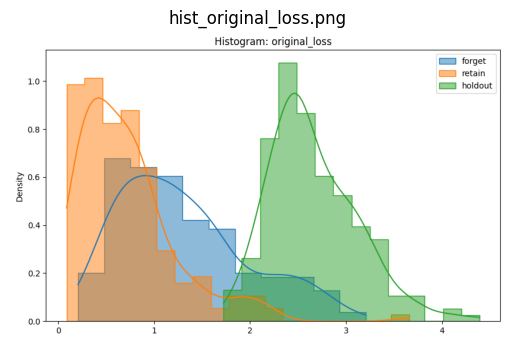

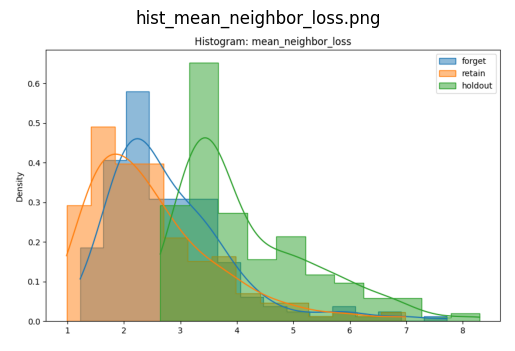

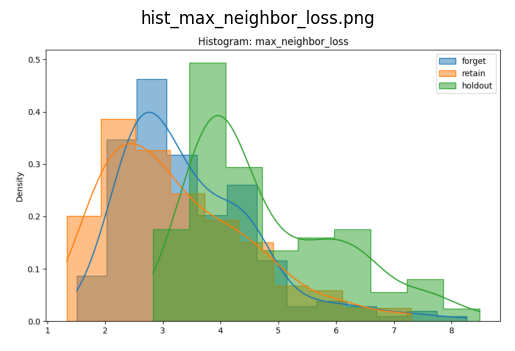

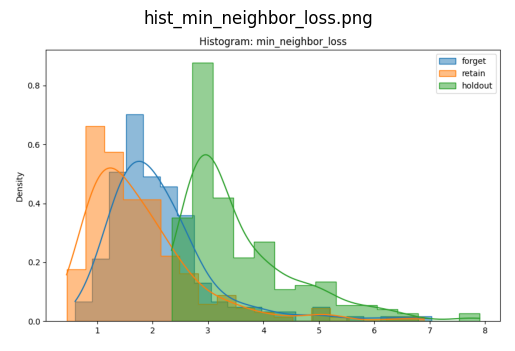

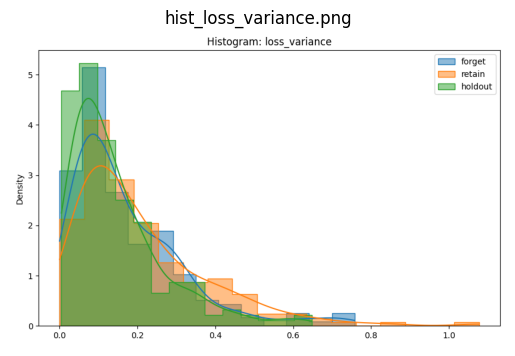

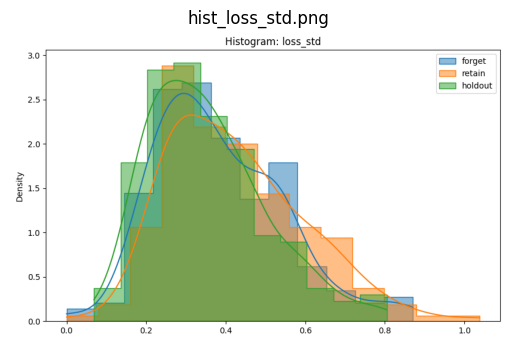

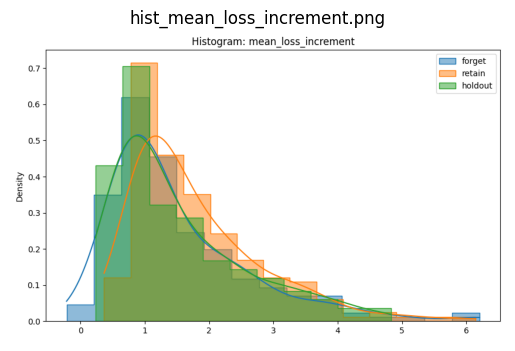

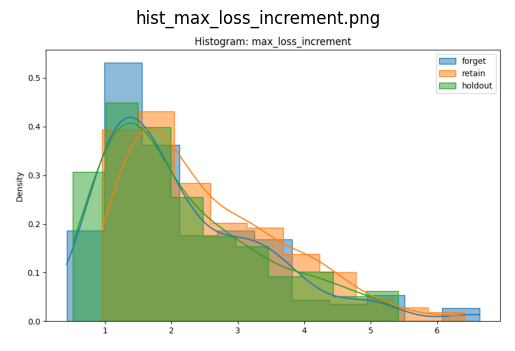

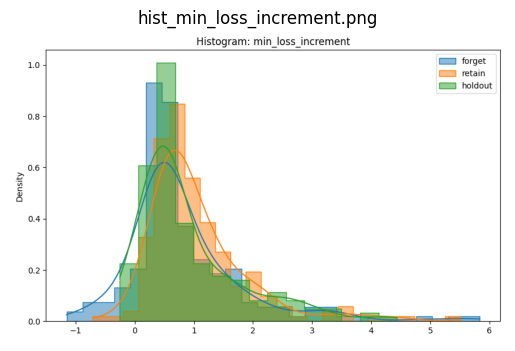

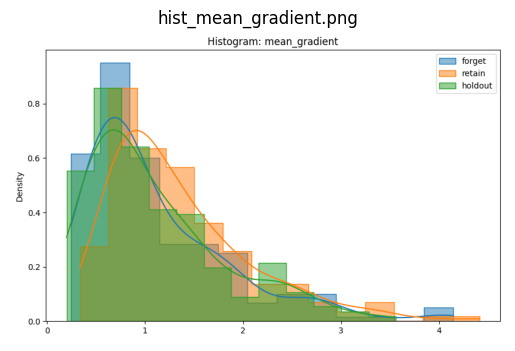

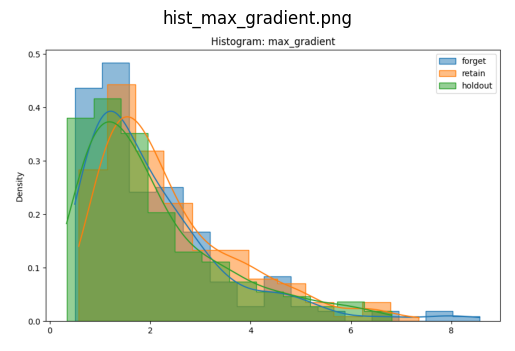

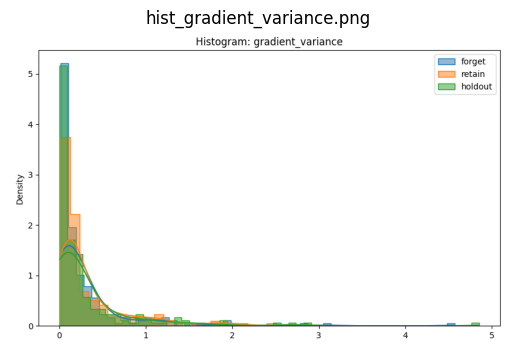

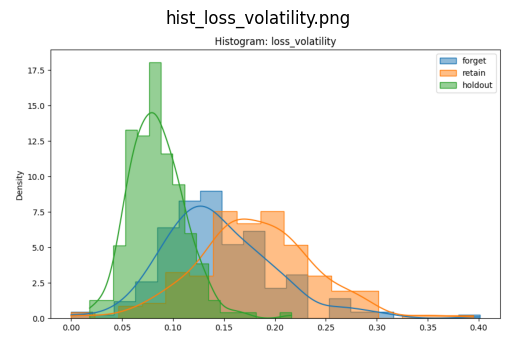

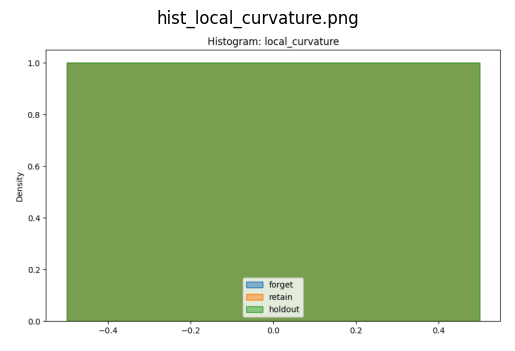

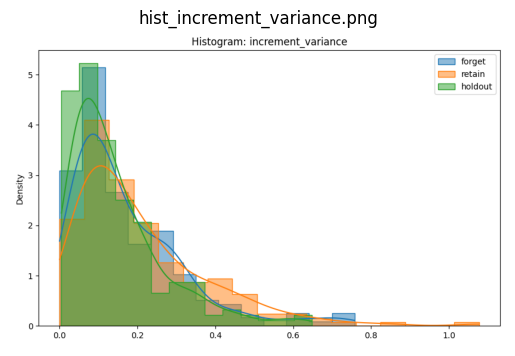

In [12]:
eval_with_ILL.show_plots(plots, ['hist'])

In [13]:
norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(forget_tensor, retain_tensor, holdout_tensor)

In [14]:
# use the function
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# Get feature labels from the features dictionary
features_labels = features_dict['forget']['features_names']

# Train predictors using normalized tensors
results, feature_importance_results = eval_with_ILL.train_predictors(
    retain_t=norm_retain_tensor,
    holdout_t=norm_holdout_tensor,
    features_labels=features_labels,
    forget_t=norm_forget_tensor
)

print("\n=== Classification Results ===")
for metric in ['accuracy', 'f1', 'roc_auc']:
    print(f"Logistic Regression {metric.upper()}: {results['multi_class']['logistic'][metric]:.3f}")
    print(f"Random Forest {metric.upper()}: {results['multi_class']['random_forest'][metric]:.3f}")
    print()



=== Classification Results ===
Logistic Regression ACCURACY: 0.756
Random Forest ACCURACY: 0.822

Logistic Regression F1: 0.751
Random Forest F1: 0.820

Logistic Regression ROC_AUC: 0.892
Random Forest ROC_AUC: 0.911



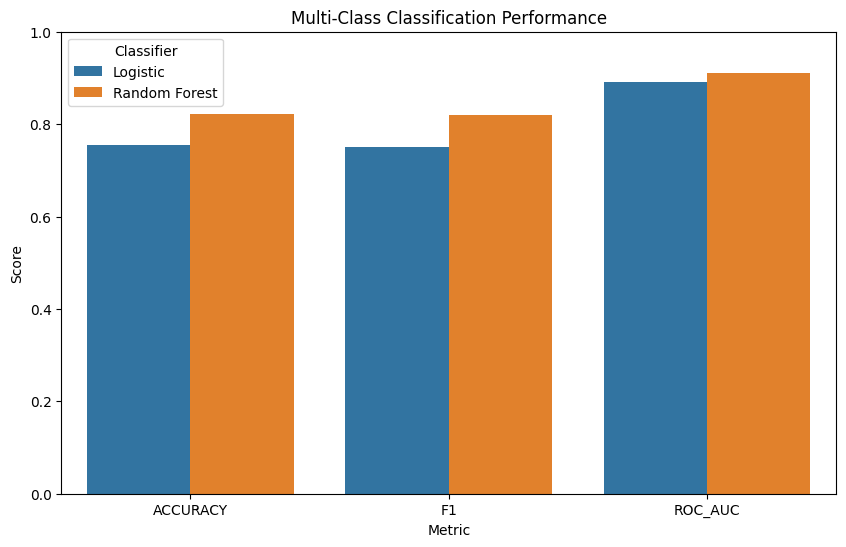

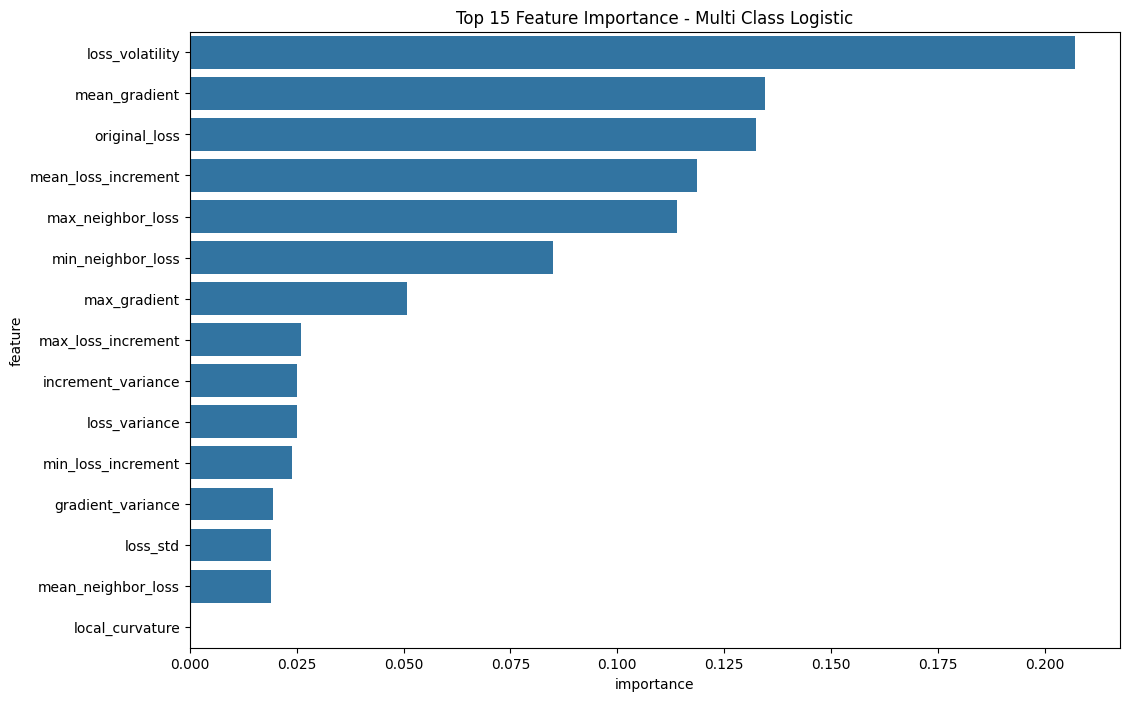

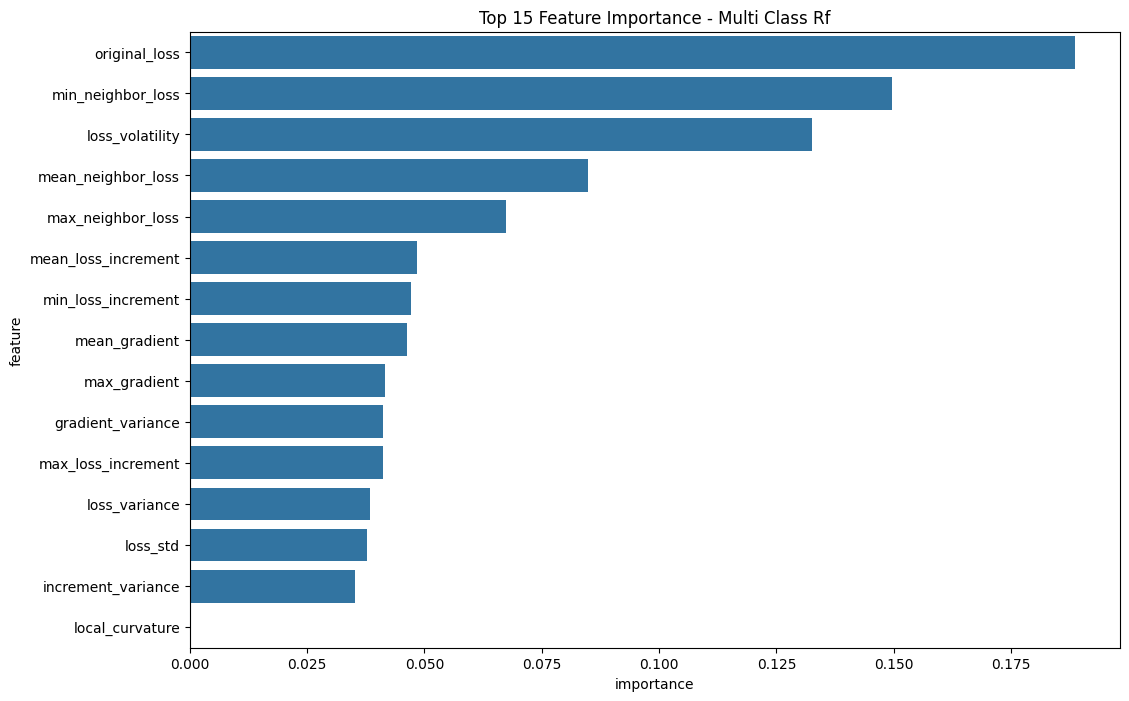

In [15]:
# Create plots
classification_plots = eval_with_ILL.plot_classification_results(results, feature_importance_results)

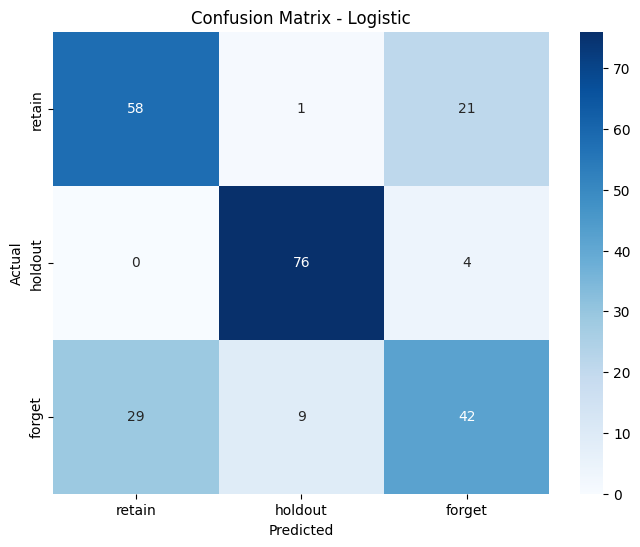

\n=== Classification Report - Logistic ===
              precision    recall  f1-score   support

      retain       0.67      0.72      0.69        80
     holdout       0.88      0.95      0.92        80
      forget       0.63      0.53      0.57        80

    accuracy                           0.73       240
   macro avg       0.73      0.73      0.73       240
weighted avg       0.73      0.73      0.73       240



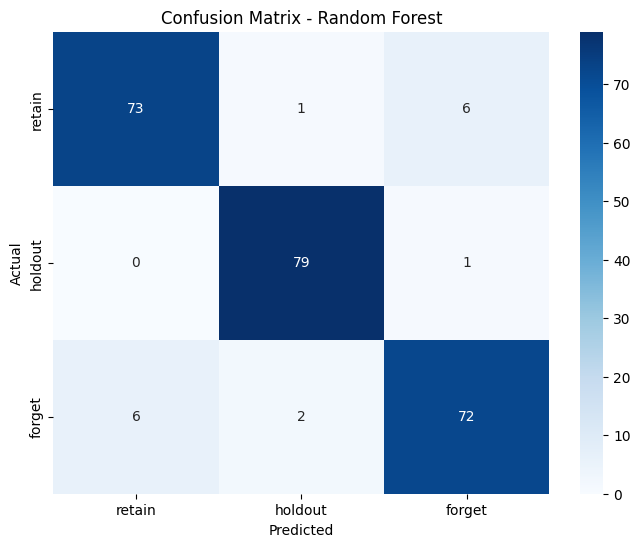

\n=== Classification Report - Random Forest ===
              precision    recall  f1-score   support

      retain       0.92      0.91      0.92        80
     holdout       0.96      0.99      0.98        80
      forget       0.91      0.90      0.91        80

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240



In [16]:
# Plot confusion matrices
eval_with_ILL.plot_confusion_matrices(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

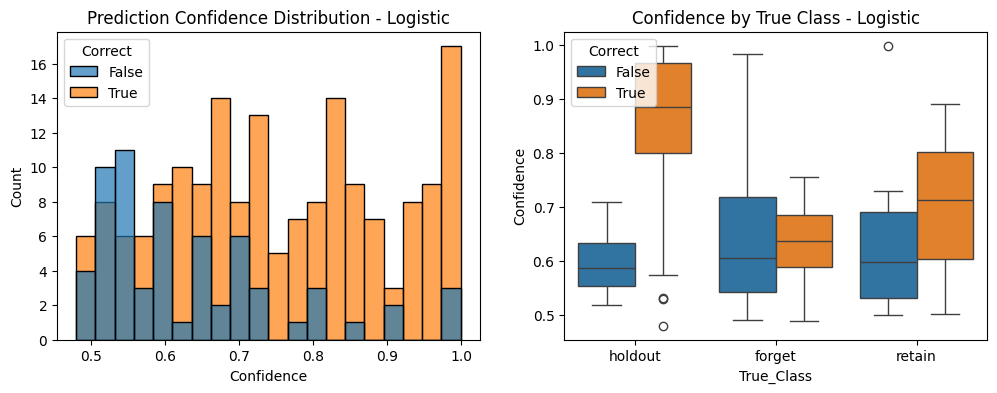

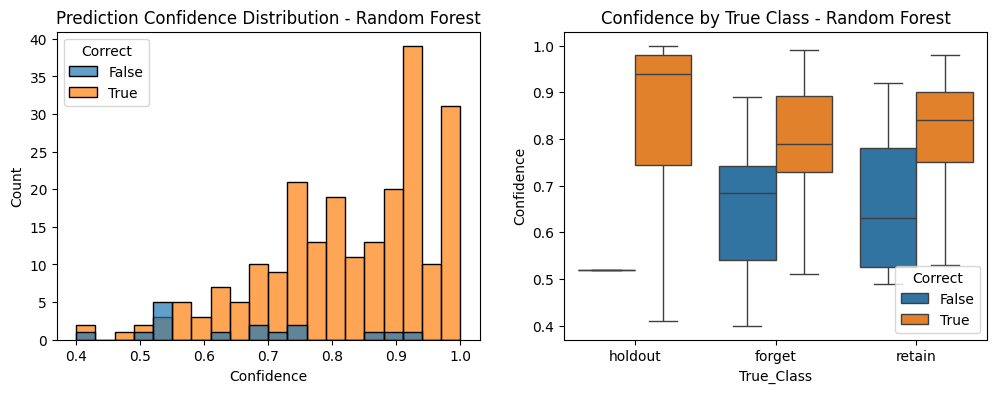


=== Summary ===
All plots have been generated and saved to the 'classification_plots' directory.
The analysis includes:
- Performance comparison between classifiers
- Feature importance for each classifier
- Confusion matrices
- Prediction confidence analysis
- Feature importance comparison between classifiers


In [17]:
# Run confidence analysis
eval_with_ILL.analyze_prediction_confidence(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("\n=== Summary ===")
print("All plots have been generated and saved to the 'classification_plots' directory.")
print("The analysis includes:")
print("- Performance comparison between classifiers")
print("- Feature importance for each classifier")
print("- Confusion matrices")
print("- Prediction confidence analysis")
print("- Feature importance comparison between classifiers")


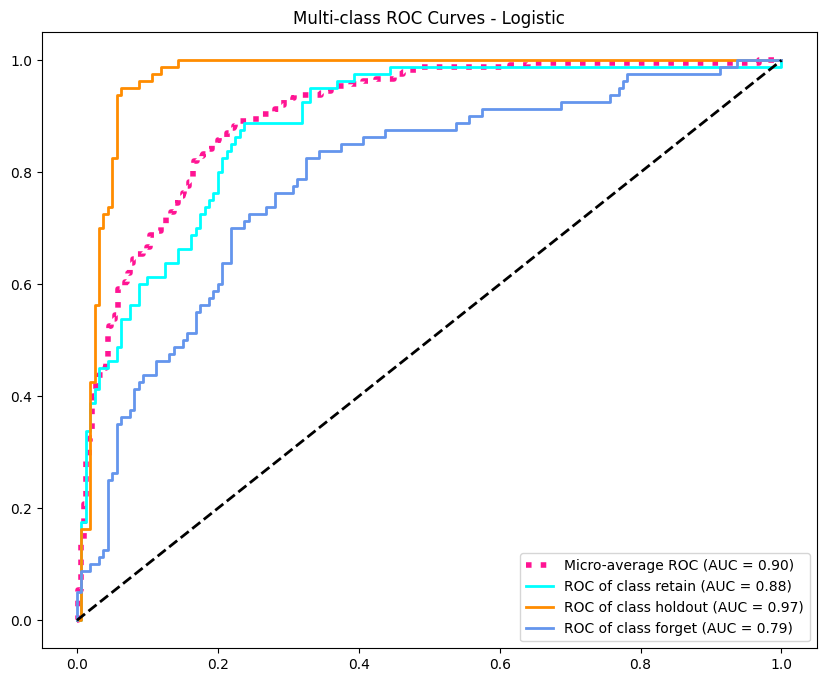

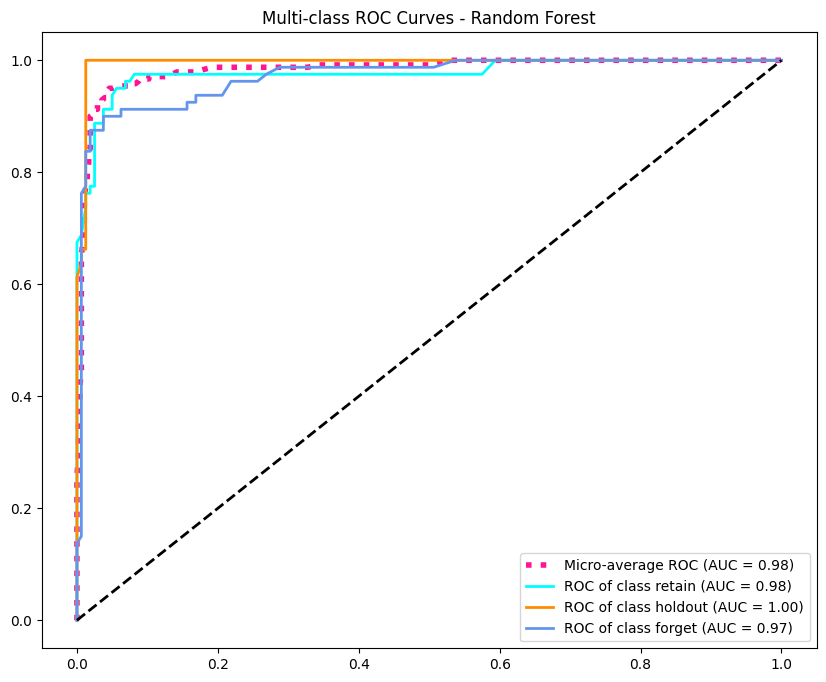

In [18]:
 # Generate ROC curves
eval_with_ILL.plot_multiclass_roc_curves(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)


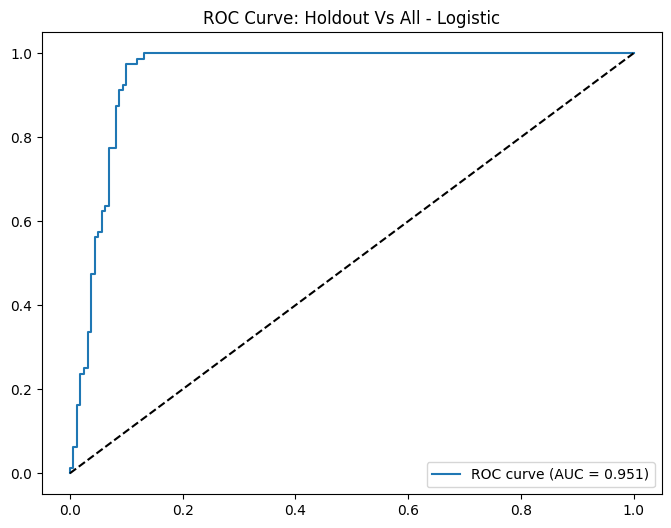

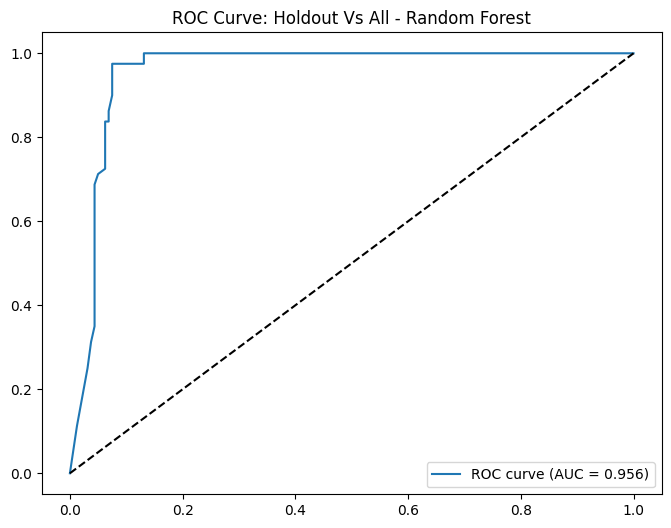

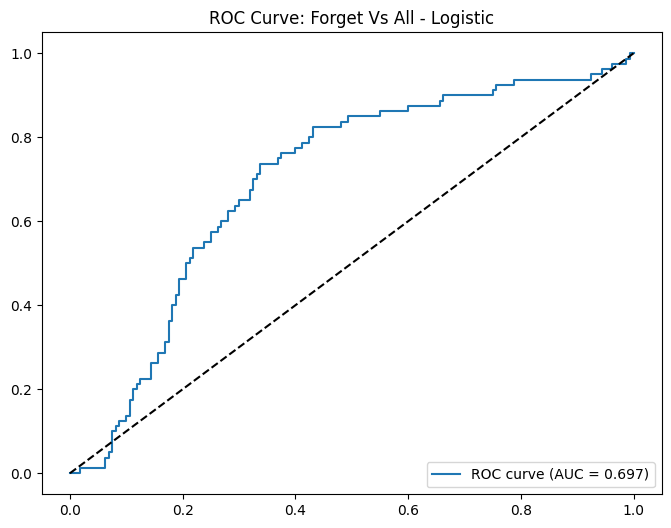

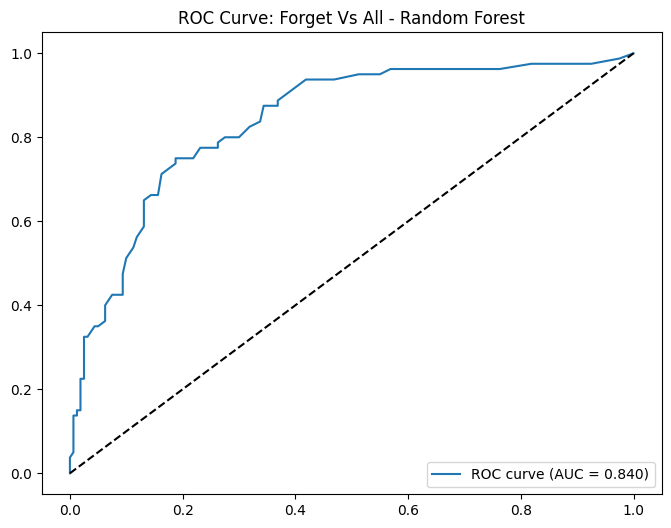

In [19]:
# Run binary comparisons
binary_results, binary_feature_importance = eval_with_ILL.train_binary_comparisons(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)


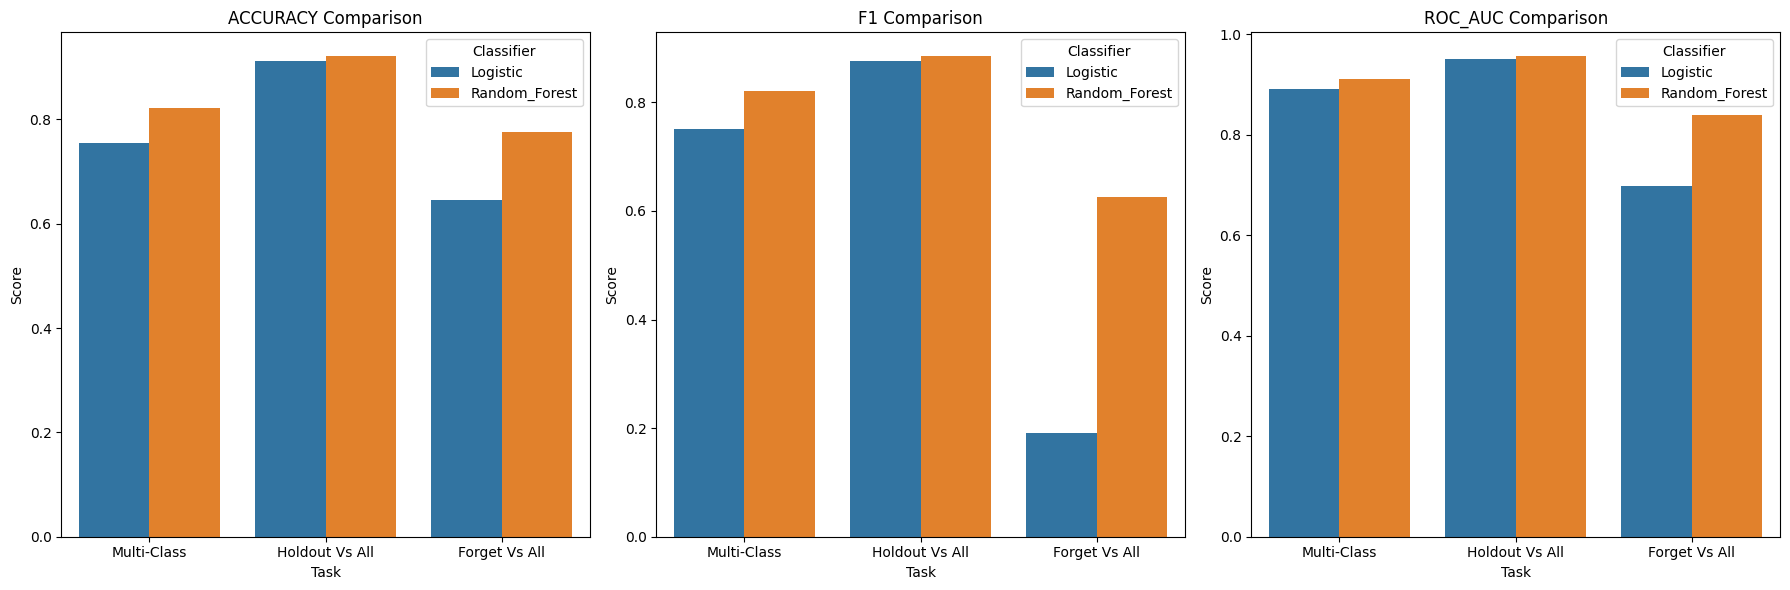

In [20]:
# Comprehensive Analysis and Summary
plots = eval_with_ILL.create_comprehensive_summary(results, binary_results, feature_importance_results, binary_feature_importance)


# Input Loss Landscape (ILL) Discriminative Analysis

This section provides specialized methods to analyze and distinguish between **forget**, **retain**, and **holdout** datasets using Input Loss Landscape features. 

## ILL Features Used:
- **Loss-based**: `original_loss`, `mean_neighbor_loss`, `max_neighbor_loss`, `min_neighbor_loss`
- **Variance-based**: `loss_variance`, `loss_std`, `increment_variance`
- **Gradient-based**: `mean_gradient`, `max_gradient`, `gradient_variance`
- **Landscape properties**: `loss_volatility`, `local_curvature`
- **Increment-based**: `mean_loss_increment`, `max_loss_increment`, `min_loss_increment`
- **Embeddings**: Sentence embeddings for semantic analysis

The goal is to identify which ILL features are most discriminative for distinguishing between the three dataset types.

In [21]:
# Additional imports for comprehensive landscape analysis
from scipy.stats import wasserstein_distance, ks_2samp, entropy, skew, kurtosis
from scipy.spatial.distance import jensenshannon, pdist, squareform
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# Try to import UMAP, install if not available
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not available. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

In [22]:
# Compute statistical distances
print("Computing statistical distances between datasets...")
stat_distances = eval_with_ILL.compute_statistical_distances(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Computing statistical distances between datasets...


# EXP: plot_statistical_distances
The plot_statistical_distances function generates heatmaps to visualize statistical distances—Wasserstein Distance, KS Statistic, and Jensen-Shannon Divergence—across features for dataset comparisons (retain, holdout, forget). Each heatmap shows how feature distributions differ between dataset pairs, with rows representing features and columns representing comparisons. Higher values indicate greater dissimilarity, helping identify features or dataset pairs with significant distributional differences. The heatmaps are annotated with precise values for clarity and saved as statistical_distances_heatmap.png.

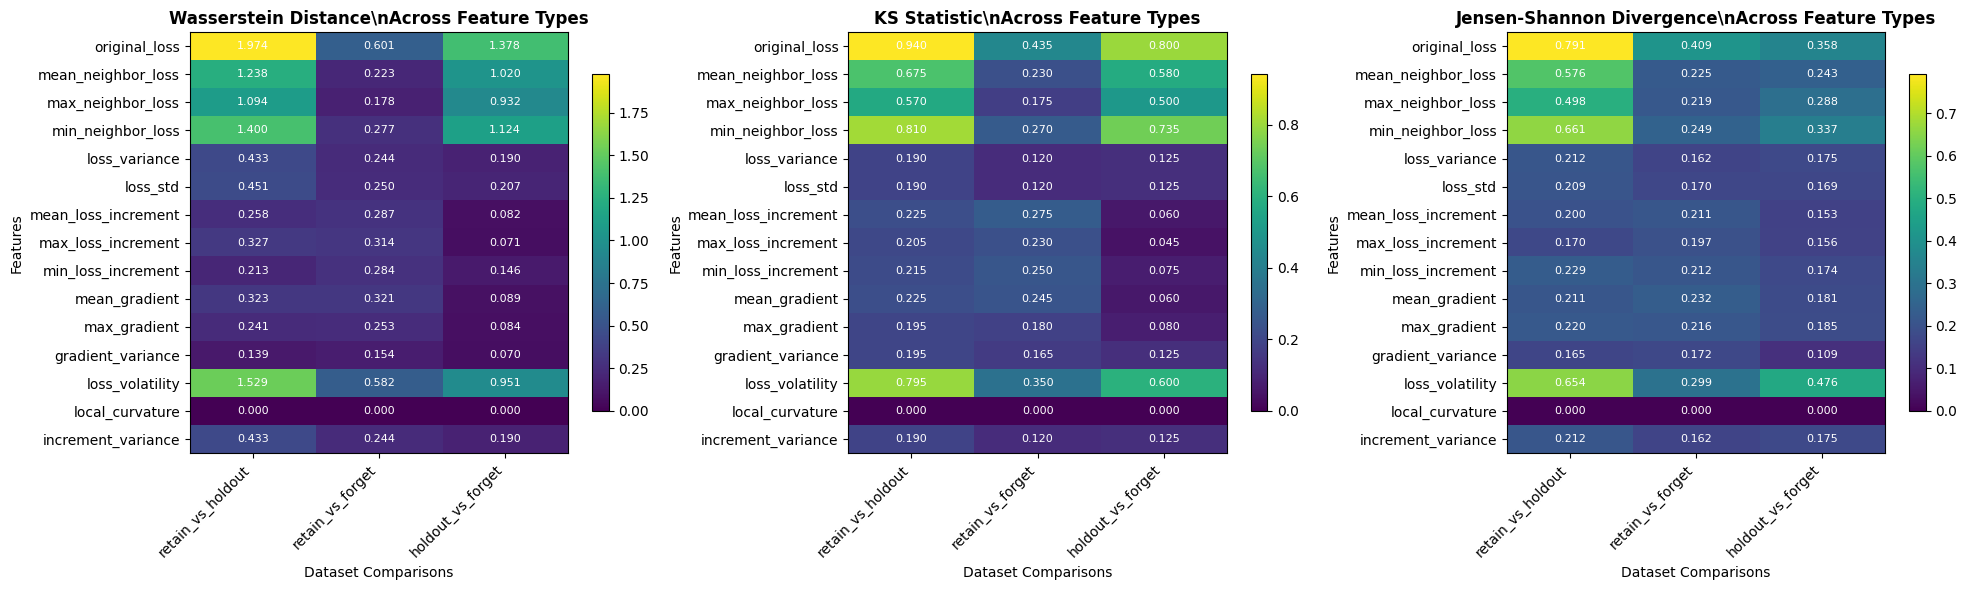

In [23]:
eval_with_ILL.plot_statistical_distances(stat_distances, features_labels)

# EXP: compare_manifold_structures
The compare_manifold_structures function visualizes the separability of datasets (retain, holdout, forget) by projecting their high-dimensional features into a 2D space using dimensionality reduction techniques such as PCA, t-SNE, Isomap, and optionally UMAP. Each plot represents the datasets as clusters of points, with colors indicating the dataset type. Well-separated clusters suggest distinct dataset characteristics, while overlapping clusters indicate shared properties. These visualizations help assess the structural differences between datasets and evaluate their separability in the feature space. The plots are saved as manifold_comparisons.png.

Analyzing manifold structures...
Computing PCA embedding...
Computing TSNE embedding...


Computing Isomap embedding...
Computing UMAP embedding...


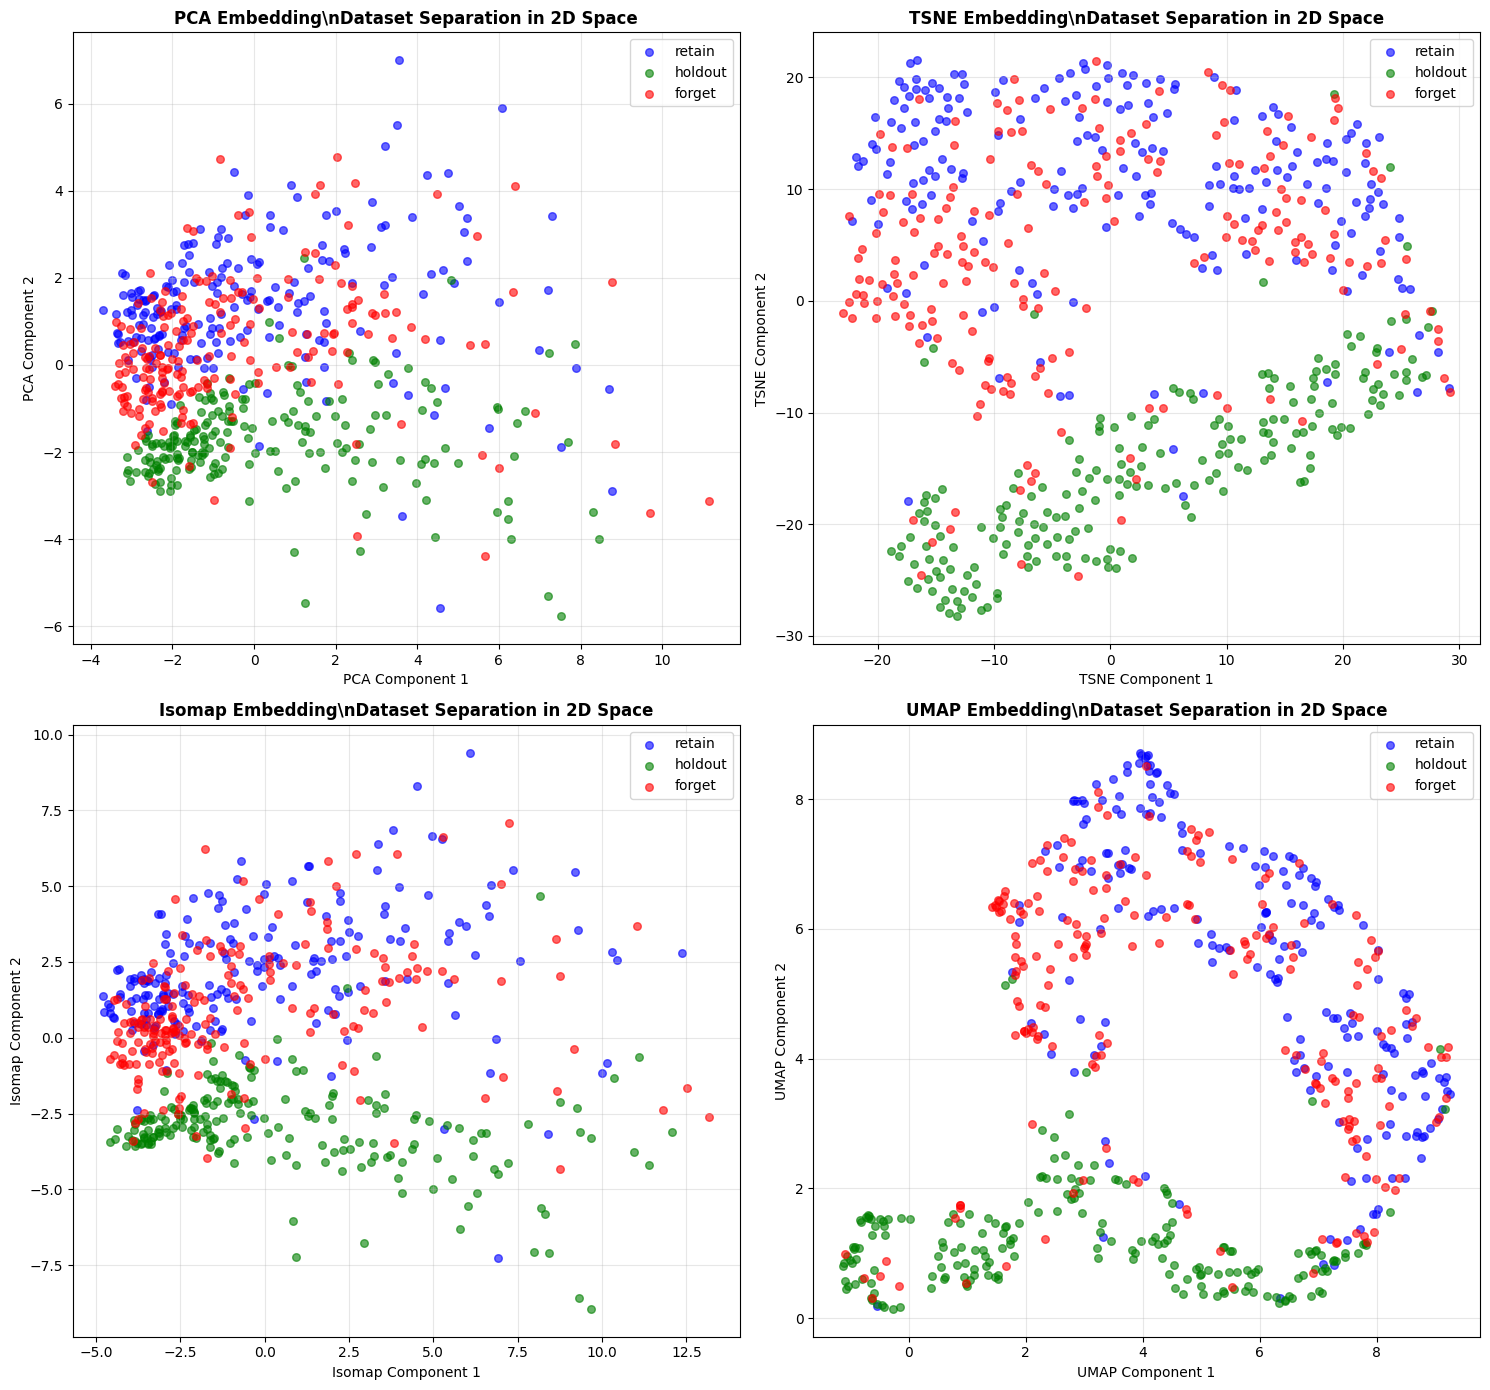

In [24]:
# Run manifold analysis
print("Analyzing manifold structures...")
manifold_results = eval_with_ILL.compare_manifold_structures(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing clustering patterns...


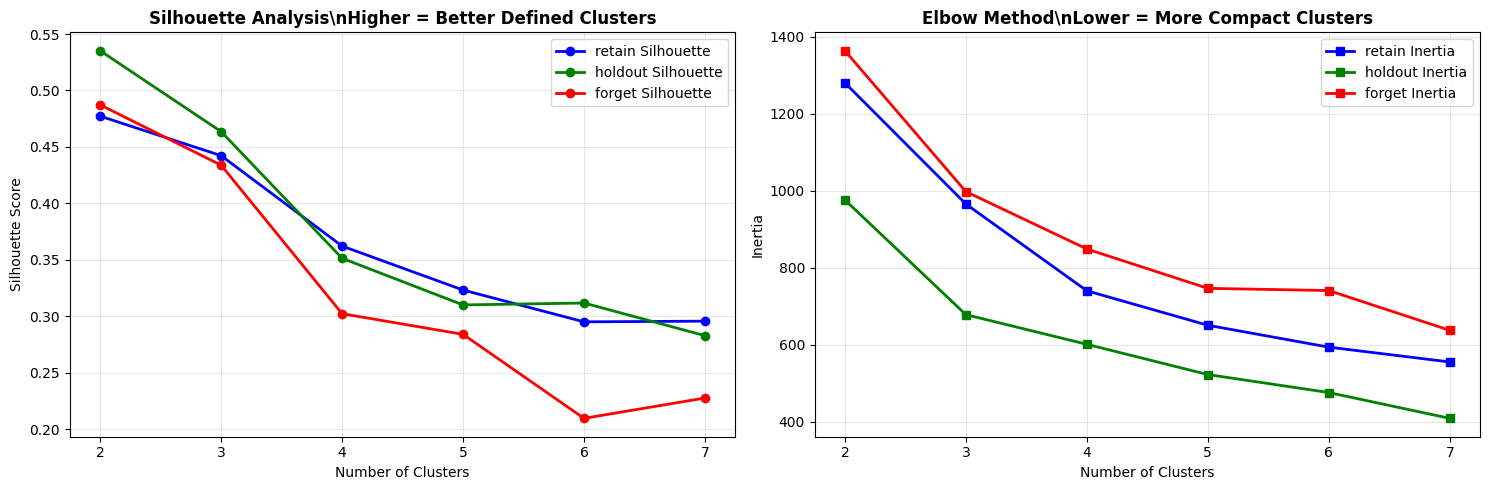

In [25]:
# Run clustering analysis
print("Analyzing clustering patterns...")
clustering_results = eval_with_ILL.analyze_clustering_patterns(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

In [26]:
# Compute topology analysis
print("Analyzing landscape topology...")
topology_results = eval_with_ILL.analyze_landscape_topology(features_dict)

Analyzing landscape topology...


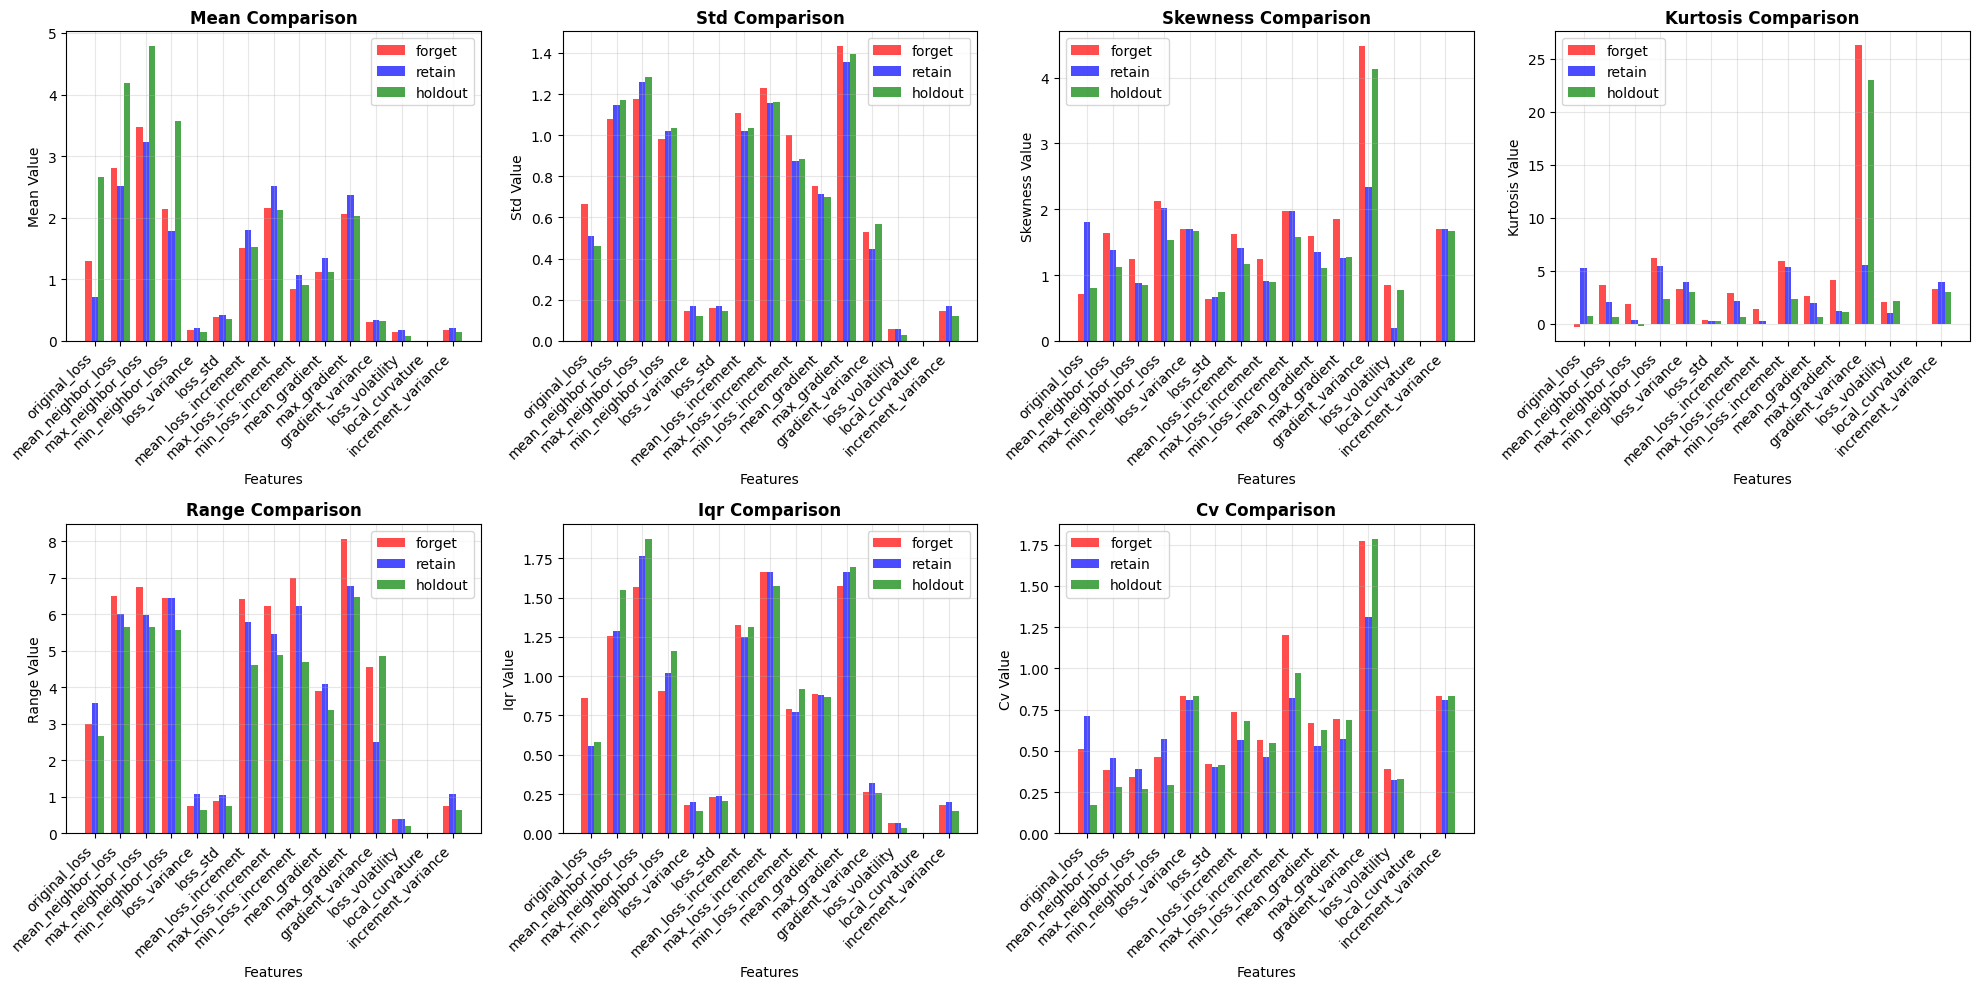

In [27]:
# Plot topology comparison
eval_with_ILL.plot_topology_comparison(topology_results, features_labels)

In [28]:
# Compute smoothness analysis
print("Analyzing landscape smoothness...")
smoothness_results = eval_with_ILL.analyze_landscape_smoothness(features_dict)

Analyzing landscape smoothness...


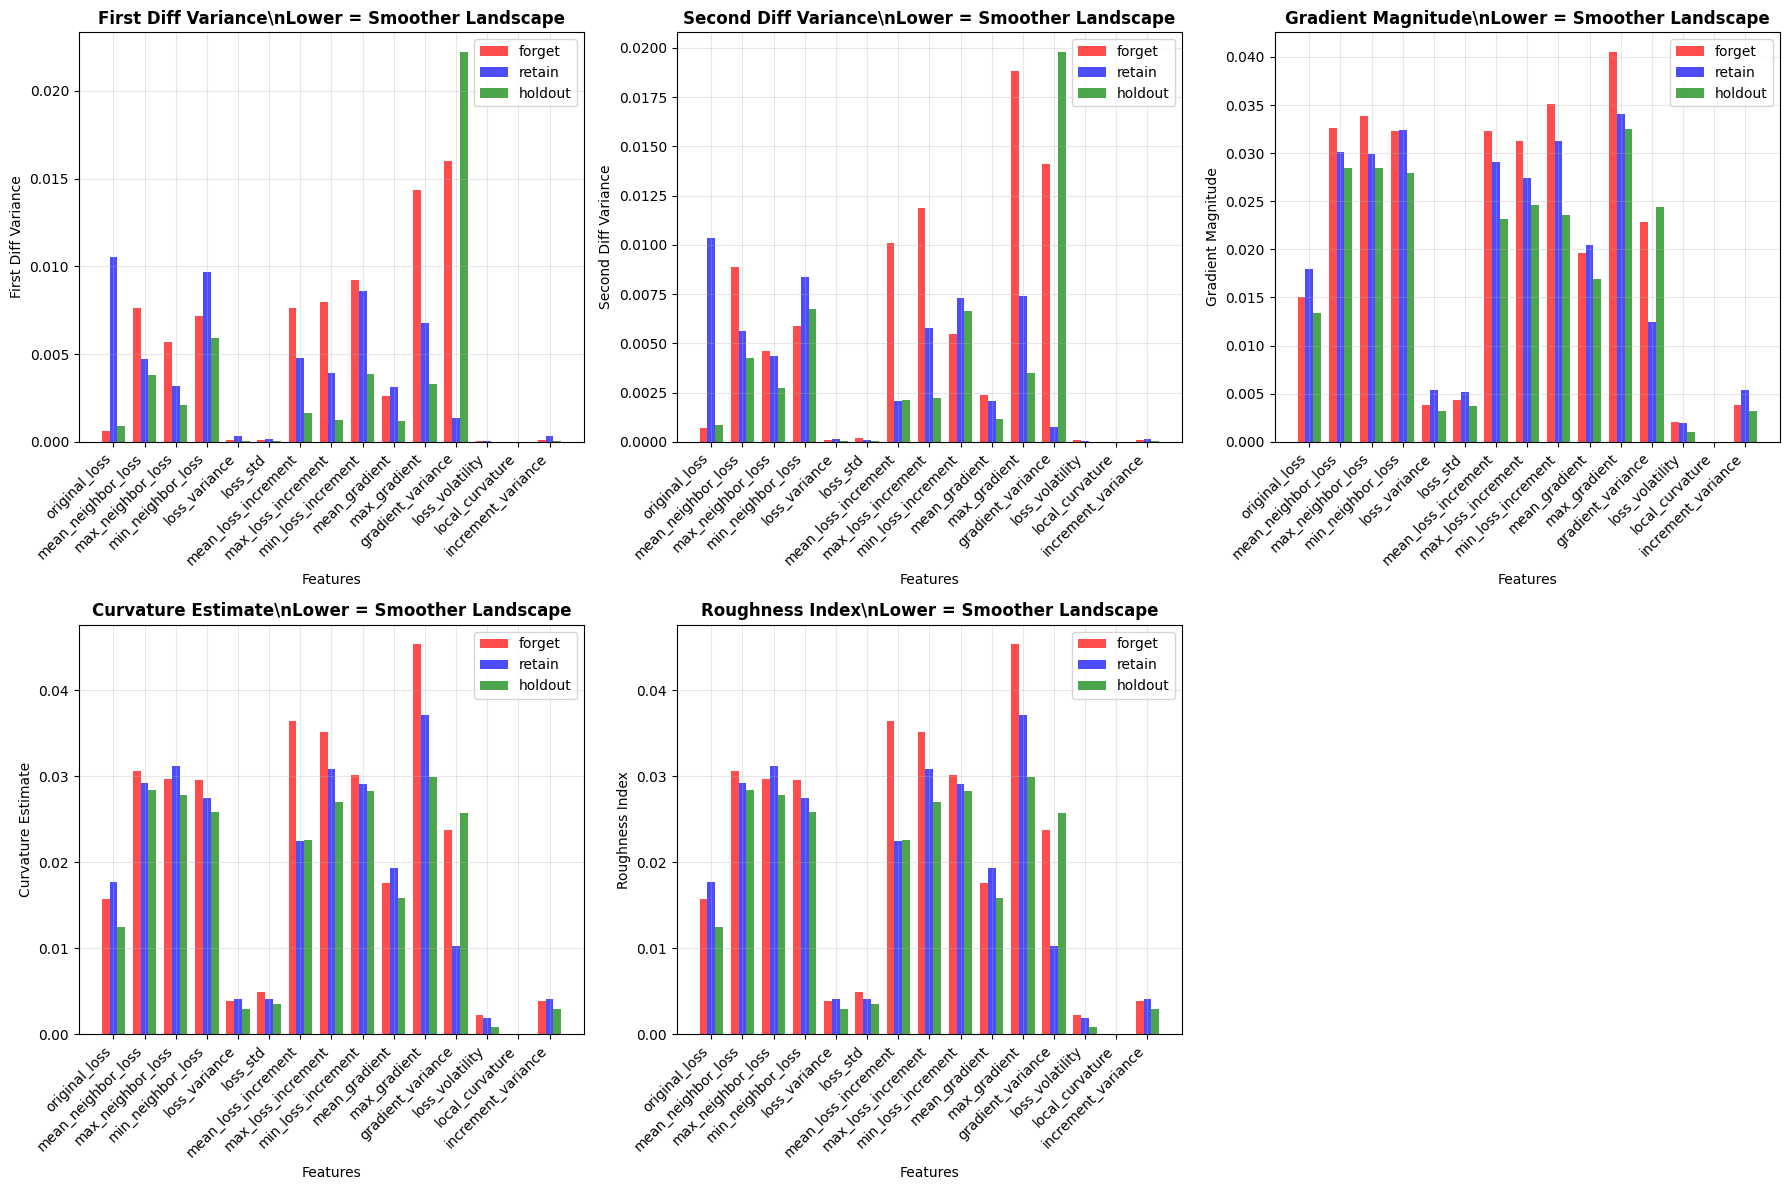

In [29]:
# Plot smoothness comparison
eval_with_ILL.plot_smoothness_comparison(smoothness_results, features_labels)

In [30]:
# Run transfer analysis
print("Analyzing prediction transfer...")
transfer_results = eval_with_ILL.analyze_prediction_transfer(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing prediction transfer...


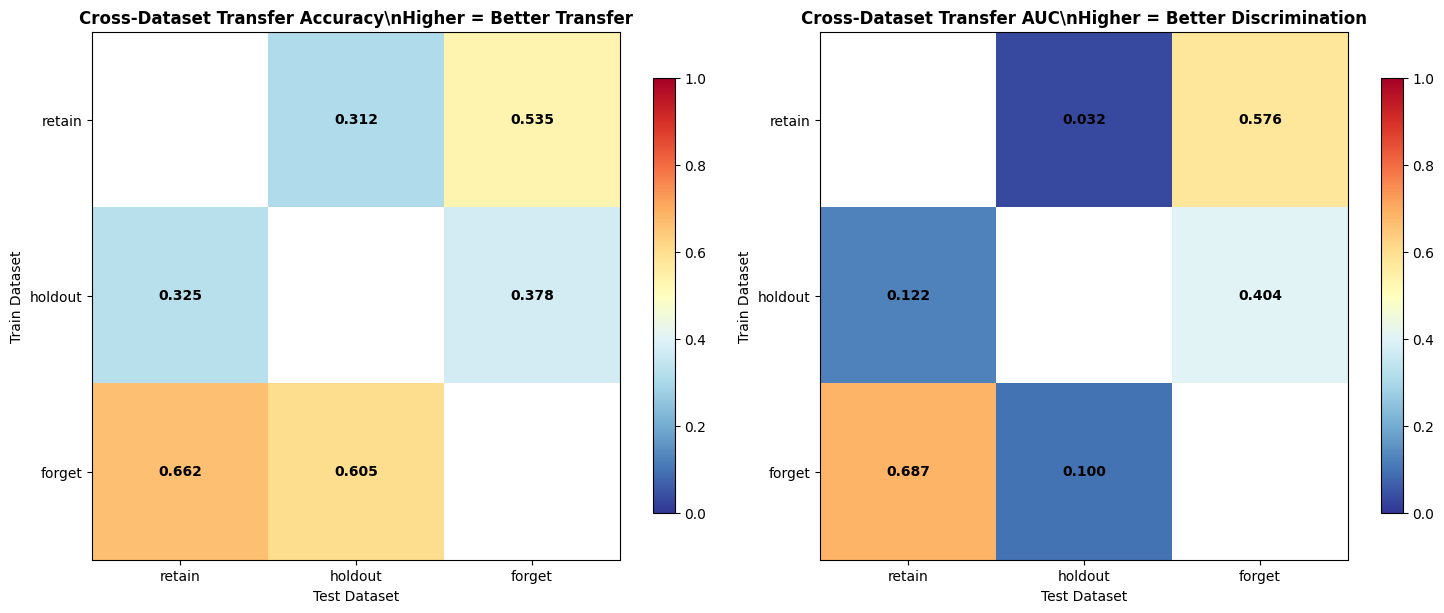

In [31]:
# Plot transfer results
eval_with_ILL.plot_transfer_results(transfer_results)

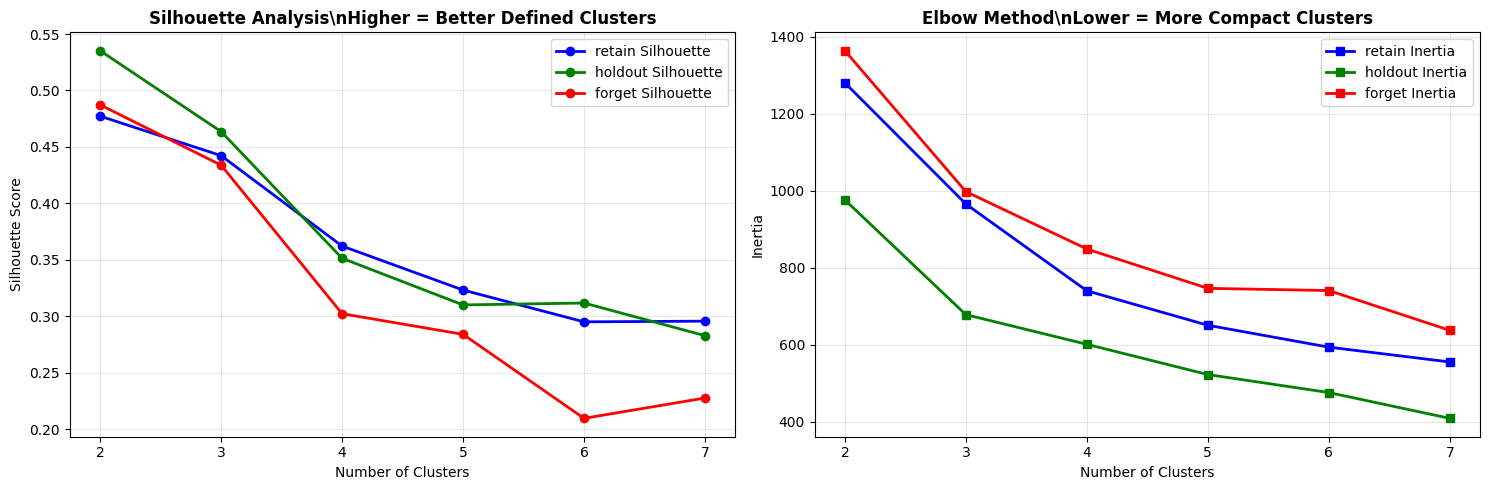

COMPREHENSIVE LANDSCAPE COMPARISON SUMMARY
\n1. STATISTICAL DISTANCES SUMMARY:
----------------------------------------
\nRETAIN_VS_HOLDOUT:
  Average Wasserstein Distance: 0.6702
  Average KS Statistic: 0.3747
  Average Jensen-Shannon Divergence: 0.3339
\nRETAIN_VS_FORGET:
  Average Wasserstein Distance: 0.2808
  Average KS Statistic: 0.2110
  Average Jensen-Shannon Divergence: 0.2090
\nHOLDOUT_VS_FORGET:
  Average Wasserstein Distance: 0.4357
  Average KS Statistic: 0.2690
  Average Jensen-Shannon Divergence: 0.2120
\n2. TOPOLOGICAL PROPERTIES SUMMARY:
----------------------------------------
\nFORGET:
  Original_Loss:
    mean: 1.3030
    std: 0.6651
    skewness: 0.7059
    kurtosis: -0.2678
    range: 2.9993
    iqr: 0.8589
    cv: 0.5105
  Mean_Neighbor_Loss:
    mean: 2.8087
    std: 1.0781
    skewness: 1.6399
    kurtosis: 3.6781
    range: 6.4926
    iqr: 1.2542
    cv: 0.3838
  Max_Neighbor_Loss:
    mean: 3.4646
    std: 1.1739
    skewness: 1.2375
    kurtosis: 1.8979
    

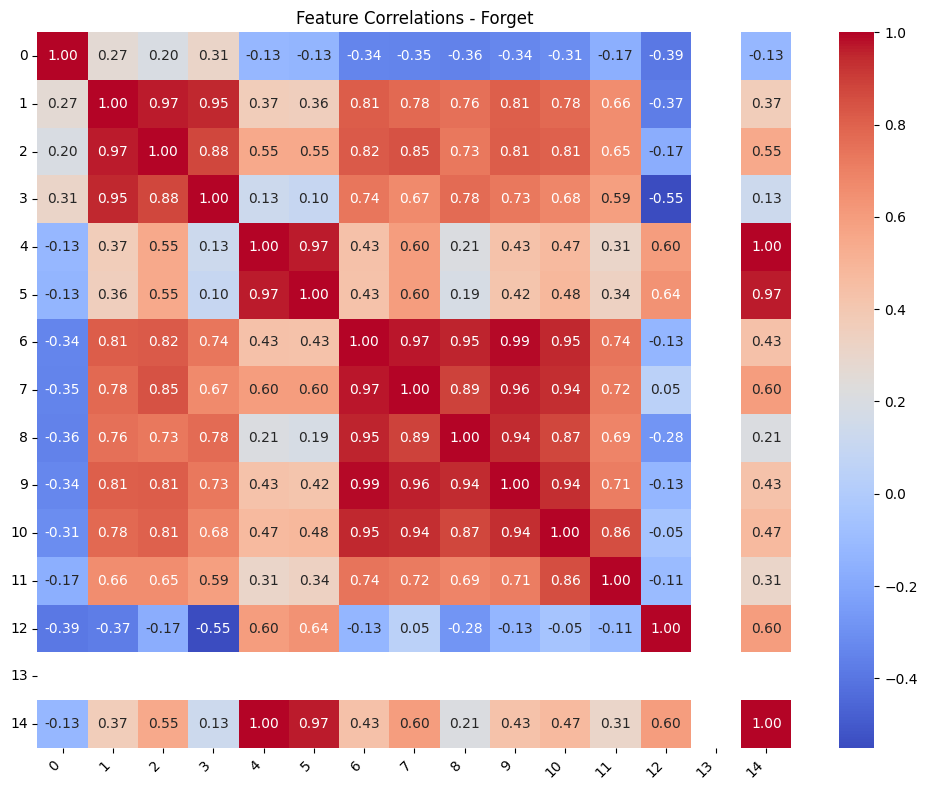

\nRETAIN:
  Original_Loss:
    mean: 0.7167
    std: 0.5114
    skewness: 1.8016
    kurtosis: 5.3110
    range: 3.5692
    iqr: 0.5564
    cv: 0.7136
  Mean_Neighbor_Loss:
    mean: 2.5151
    std: 1.1457
    skewness: 1.3724
    kurtosis: 2.0605
    range: 5.9977
    iqr: 1.2900
    cv: 0.4555
  Max_Neighbor_Loss:
    mean: 3.2361
    std: 1.2609
    skewness: 0.8822
    kurtosis: 0.3717
    range: 5.9626
    iqr: 1.7637
    cv: 0.3896
  Min_Neighbor_Loss:
    mean: 1.7843
    std: 1.0215
    skewness: 2.0234
    kurtosis: 5.4836
    range: 6.4506
    iqr: 1.0191
    cv: 0.5725
  Loss_Variance:
    mean: 0.2089
    std: 0.1687
    skewness: 1.6988
    kurtosis: 3.9210
    range: 1.0779
    iqr: 0.1963
    cv: 0.8077
  Loss_Std:
    mean: 0.4240
    std: 0.1707
    skewness: 0.6612
    kurtosis: 0.2964
    range: 1.0382
    iqr: 0.2397
    cv: 0.4026
  Mean_Loss_Increment:
    mean: 1.7985
    std: 1.0185
    skewness: 1.4152
    kurtosis: 2.1611
    range: 5.7785
    iqr: 1.2489
    

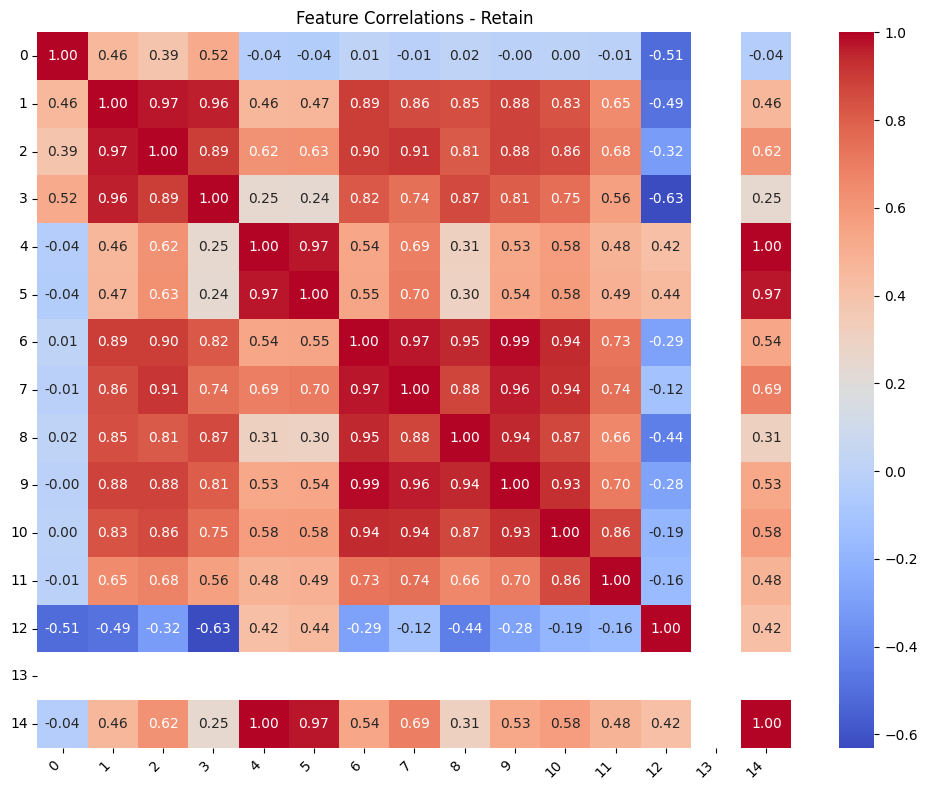

\nHOLDOUT:
  Original_Loss:
    mean: 2.6584
    std: 0.4592
    skewness: 0.7965
    kurtosis: 0.7767
    range: 2.6688
    iqr: 0.5833
    cv: 0.1727
  Mean_Neighbor_Loss:
    mean: 4.1830
    std: 1.1720
    skewness: 1.1250
    kurtosis: 0.6727
    range: 5.6545
    iqr: 1.5507
    cv: 0.2802
  Max_Neighbor_Loss:
    mean: 4.7866
    std: 1.2849
    skewness: 0.8531
    kurtosis: -0.1673
    range: 5.6546
    iqr: 1.8749
    cv: 0.2684
  Min_Neighbor_Loss:
    mean: 3.5704
    std: 1.0352
    skewness: 1.5290
    kurtosis: 2.3073
    range: 5.5593
    iqr: 1.1583
    cv: 0.2900
  Loss_Variance:
    mean: 0.1447
    std: 0.1206
    skewness: 1.6670
    kurtosis: 3.0252
    range: 0.6430
    iqr: 0.1396
    cv: 0.8329
  Loss_Std:
    mean: 0.3519
    std: 0.1447
    skewness: 0.7476
    kurtosis: 0.2303
    range: 0.7361
    iqr: 0.2040
    cv: 0.4113
  Mean_Loss_Increment:
    mean: 1.5247
    std: 1.0333
    skewness: 1.1656
    kurtosis: 0.6498
    range: 4.5994
    iqr: 1.3112
  

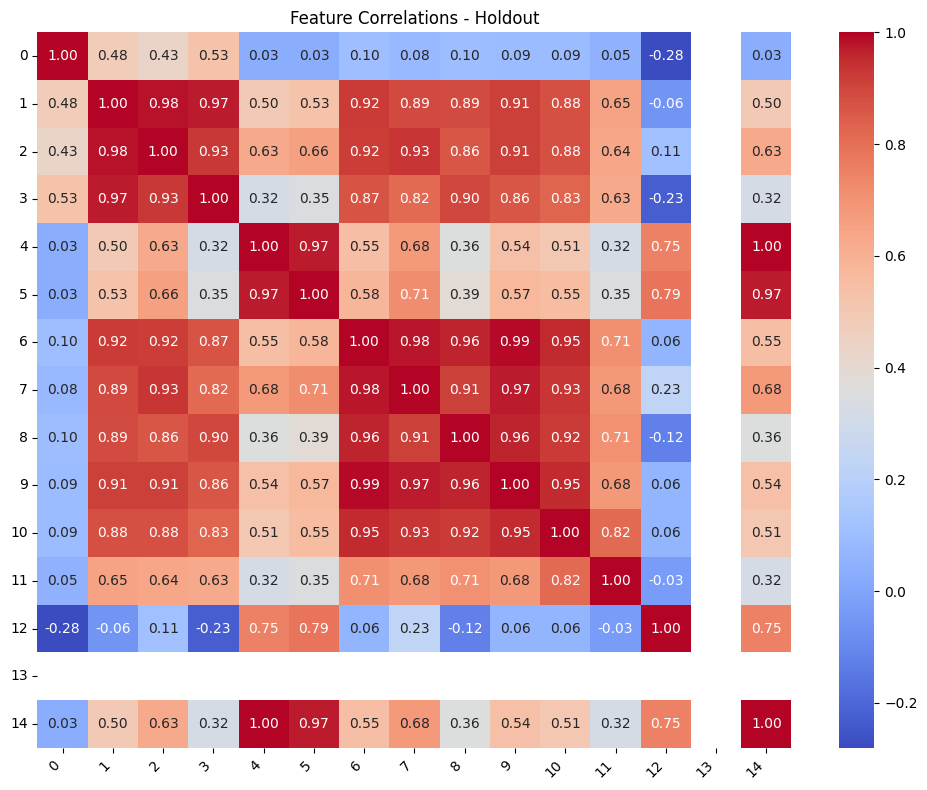

\n3. CLUSTERING PATTERNS SUMMARY:
----------------------------------------
  Retain: Best Silhouette = 0.4773, Best Inertia = 555.5264
  Holdout: Best Silhouette = 0.5352, Best Inertia = 409.1456
  Forget: Best Silhouette = 0.4873, Best Inertia = 637.6901
\n4. SMOOTHNESS ANALYSIS SUMMARY:
----------------------------------------
  Forget:
    First Diff Var: 0.0053
    Second Diff Var: 0.0056
    Gradient Magnitude: 0.0206
    Curvature Estimate: 0.0206
    Roughness Index: 0.0206
  Retain:
    First Diff Var: 0.0038
    Second Diff Var: 0.0036
    Gradient Magnitude: 0.0189
    Curvature Estimate: 0.0179
    Roughness Index: 0.0179
  Holdout:
    First Diff Var: 0.0031
    Second Diff Var: 0.0033
    Gradient Magnitude: 0.0170
    Curvature Estimate: 0.0169
    Roughness Index: 0.0169
\n5. TRANSFER LEARNING RESULTS SUMMARY:
----------------------------------------
  train_retain_test_holdout: Accuracy = 0.3117, AUC = 0.0321
  train_retain_test_forget: Accuracy = 0.5350, AUC = 0.5757
 

In [32]:
# Generate comprehensive summary
clustering_results = eval_with_ILL.analyze_clustering_patterns(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)
eval_with_ILL.create_landscape_summary_report(stat_distances, topology_results, smoothness_results, transfer_results, clustering_results)

In [33]:
# Final comprehensive comparison - Run all methods together
print("Running comprehensive landscape analysis...")
print("This will generate multiple comparison plots and a summary report.")

# Create a summary of all results
comprehensive_results = {
    'statistical_distances': stat_distances,
    'manifold_results': manifold_results,
    'clustering_results': clustering_results,
    'topology_results': topology_results,
    'smoothness_results': smoothness_results,
    'transfer_results': transfer_results
}

# Save results for future reference
import pickle
results_file = f'{plots_base_dir}/comprehensive_landscape_results.pkl'
with open(results_file, 'wb') as f:
    pickle.dump(comprehensive_results, f)

print(f"\nAll results saved to: {results_file}")
print(f"All plots saved to: {plots_base_dir}/")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("Generated plots:")
print("1. Statistical distances heatmap")
print("2. Manifold embeddings (PCA, t-SNE, UMAP, Isomap)")
print("3. Clustering analysis (Silhouette & Elbow)")
print("4. Topological properties comparison")
print("5. Landscape smoothness comparison")
print("6. Transfer learning performance")
print("="*60)

Running comprehensive landscape analysis...
This will generate multiple comparison plots and a summary report.

All results saved to: loss_landscape_plots/comprehensive_landscape_results.pkl
All plots saved to: loss_landscape_plots/

ANALYSIS COMPLETE!
Generated plots:
1. Statistical distances heatmap
2. Manifold embeddings (PCA, t-SNE, UMAP, Isomap)
3. Clustering analysis (Silhouette & Elbow)
4. Topological properties comparison
5. Landscape smoothness comparison
6. Transfer learning performance


In [34]:
# ============================================================================
# SPECIALIZED ILL DISCRIMINATIVE ANALYSIS
# ============================================================================

# Run ILL discrimination analysis
print("Analyzing ILL feature discrimination...")
ill_discrimination = eval_with_ILL.analyze_ill_feature_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing ILL feature discrimination...
ILL FEATURE DISCRIMINATION ANALYSIS
Cross-validation accuracy: 0.747 (+/- 0.070)
Overall classification accuracy: 1.000

Top 5 Most Discriminative ILL Features:
1. original_loss: 0.2118
2. min_neighbor_loss: 0.1425
3. loss_volatility: 0.1244
4. mean_neighbor_loss: 0.0828
5. max_neighbor_loss: 0.0716


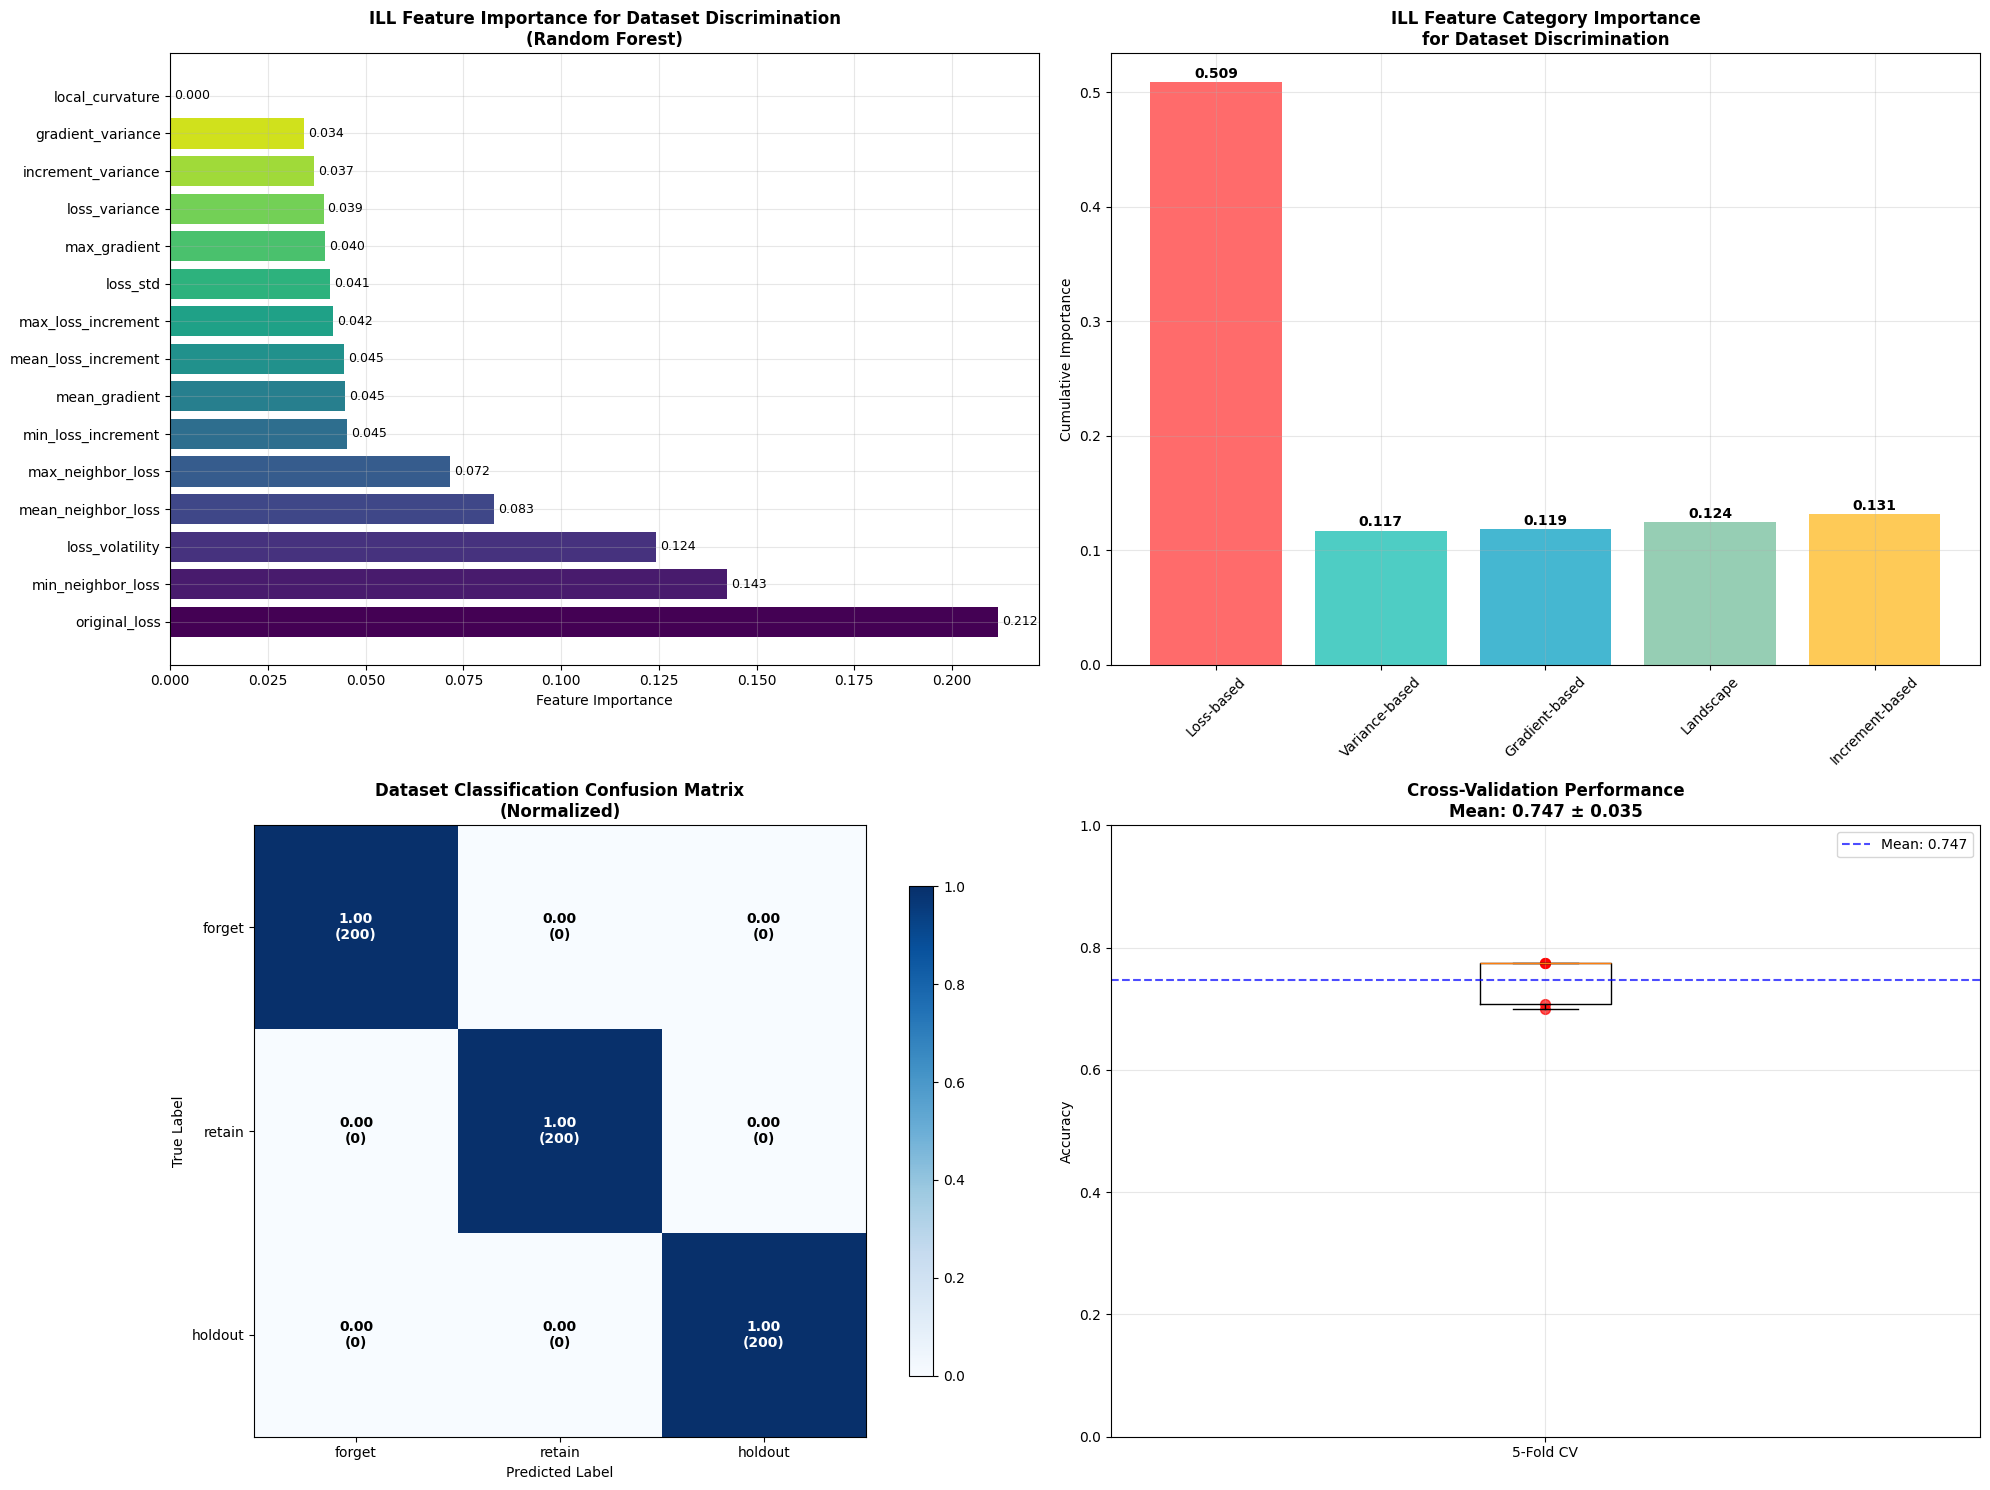

In [35]:
# Plot ILL discrimination analysis
eval_with_ILL.plot_ill_discrimination_analysis(ill_discrimination, features_labels)

In [36]:
# Run loss landscape topology discrimination analysis
print("Analyzing loss landscape topology for discrimination...")
topology_discrimination = eval_with_ILL.analyze_loss_landscape_topology_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing loss landscape topology for discrimination...
LOSS LANDSCAPE TOPOLOGY DISCRIMINATION ANALYSIS

LOSS FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.448
    Max effect size: 0.988
  forget vs holdout:
    Average effect size: 1.521
    Max effect size: 2.372
  retain vs holdout:
    Average effect size: 2.097
    Max effect size: 3.995

VARIANCE FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.235
    Max effect size: 0.245
  forget vs holdout:
    Average effect size: 0.210
    Max effect size: 0.211
  retain vs holdout:
    Average effect size: 0.444
    Max effect size: 0.456

GRADIENT FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.204
    Max effect size: 0.309
  forget vs holdout:
    Average effect size: 0.023
    Max effect size: 0.036
  retain vs holdout:
    Average effect size: 0.206
    Max effect size: 0.333

LANDSCAPE FEATURES:
------------------

In [37]:
# Run boundary analysis
print("Analyzing loss landscape boundaries...")
boundary_results = eval_with_ILL.analyze_loss_landscape_boundaries(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing loss landscape boundaries...
LOSS LANDSCAPE BOUNDARY ANALYSIS
Testing different classifiers to understand decision boundary complexity...
Linear SVM     : CV=0.742±0.020, Train=0.755
RBF SVM        : CV=0.720±0.029, Train=0.772
Decision Tree  : CV=0.687±0.036, Train=0.940
Naive Bayes    : CV=0.705±0.044, Train=0.715
Random Forest  : CV=0.750±0.029, Train=1.000


In [38]:
# Run pairwise discrimination analysis
print("Analyzing pairwise discrimination...")
pairwise_results = eval_with_ILL.analyze_pairwise_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing pairwise discrimination...
PAIRWISE DISCRIMINATION ANALYSIS

FORGET vs RETAIN:
-------------------------
Binary classification accuracy: 0.680 ± 0.064
Significant features: 12/15
Top 3 discriminative features:
  original_loss: Cohen's d = 0.988, p = 0.0000
  loss_volatility: Cohen's d = -0.645, p = 0.0000
  min_neighbor_loss: Cohen's d = 0.352, p = 0.0005

FORGET vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.932 ± 0.010
Significant features: 8/15
Top 3 discriminative features:
  original_loss: Cohen's d = -2.372, p = 0.0000
  min_neighbor_loss: Cohen's d = -1.419, p = 0.0000
  loss_volatility: Cohen's d = 1.356, p = 0.0000

RETAIN vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.972 ± 0.012
Significant features: 12/15
Top 3 discriminative features:
  original_loss: Cohen's d = -3.995, p = 0.0000
  loss_volatility: Cohen's d = 2.125, p = 0.0000
  min_neighbor_loss: Cohen's d = -1.737, p = 0.0000


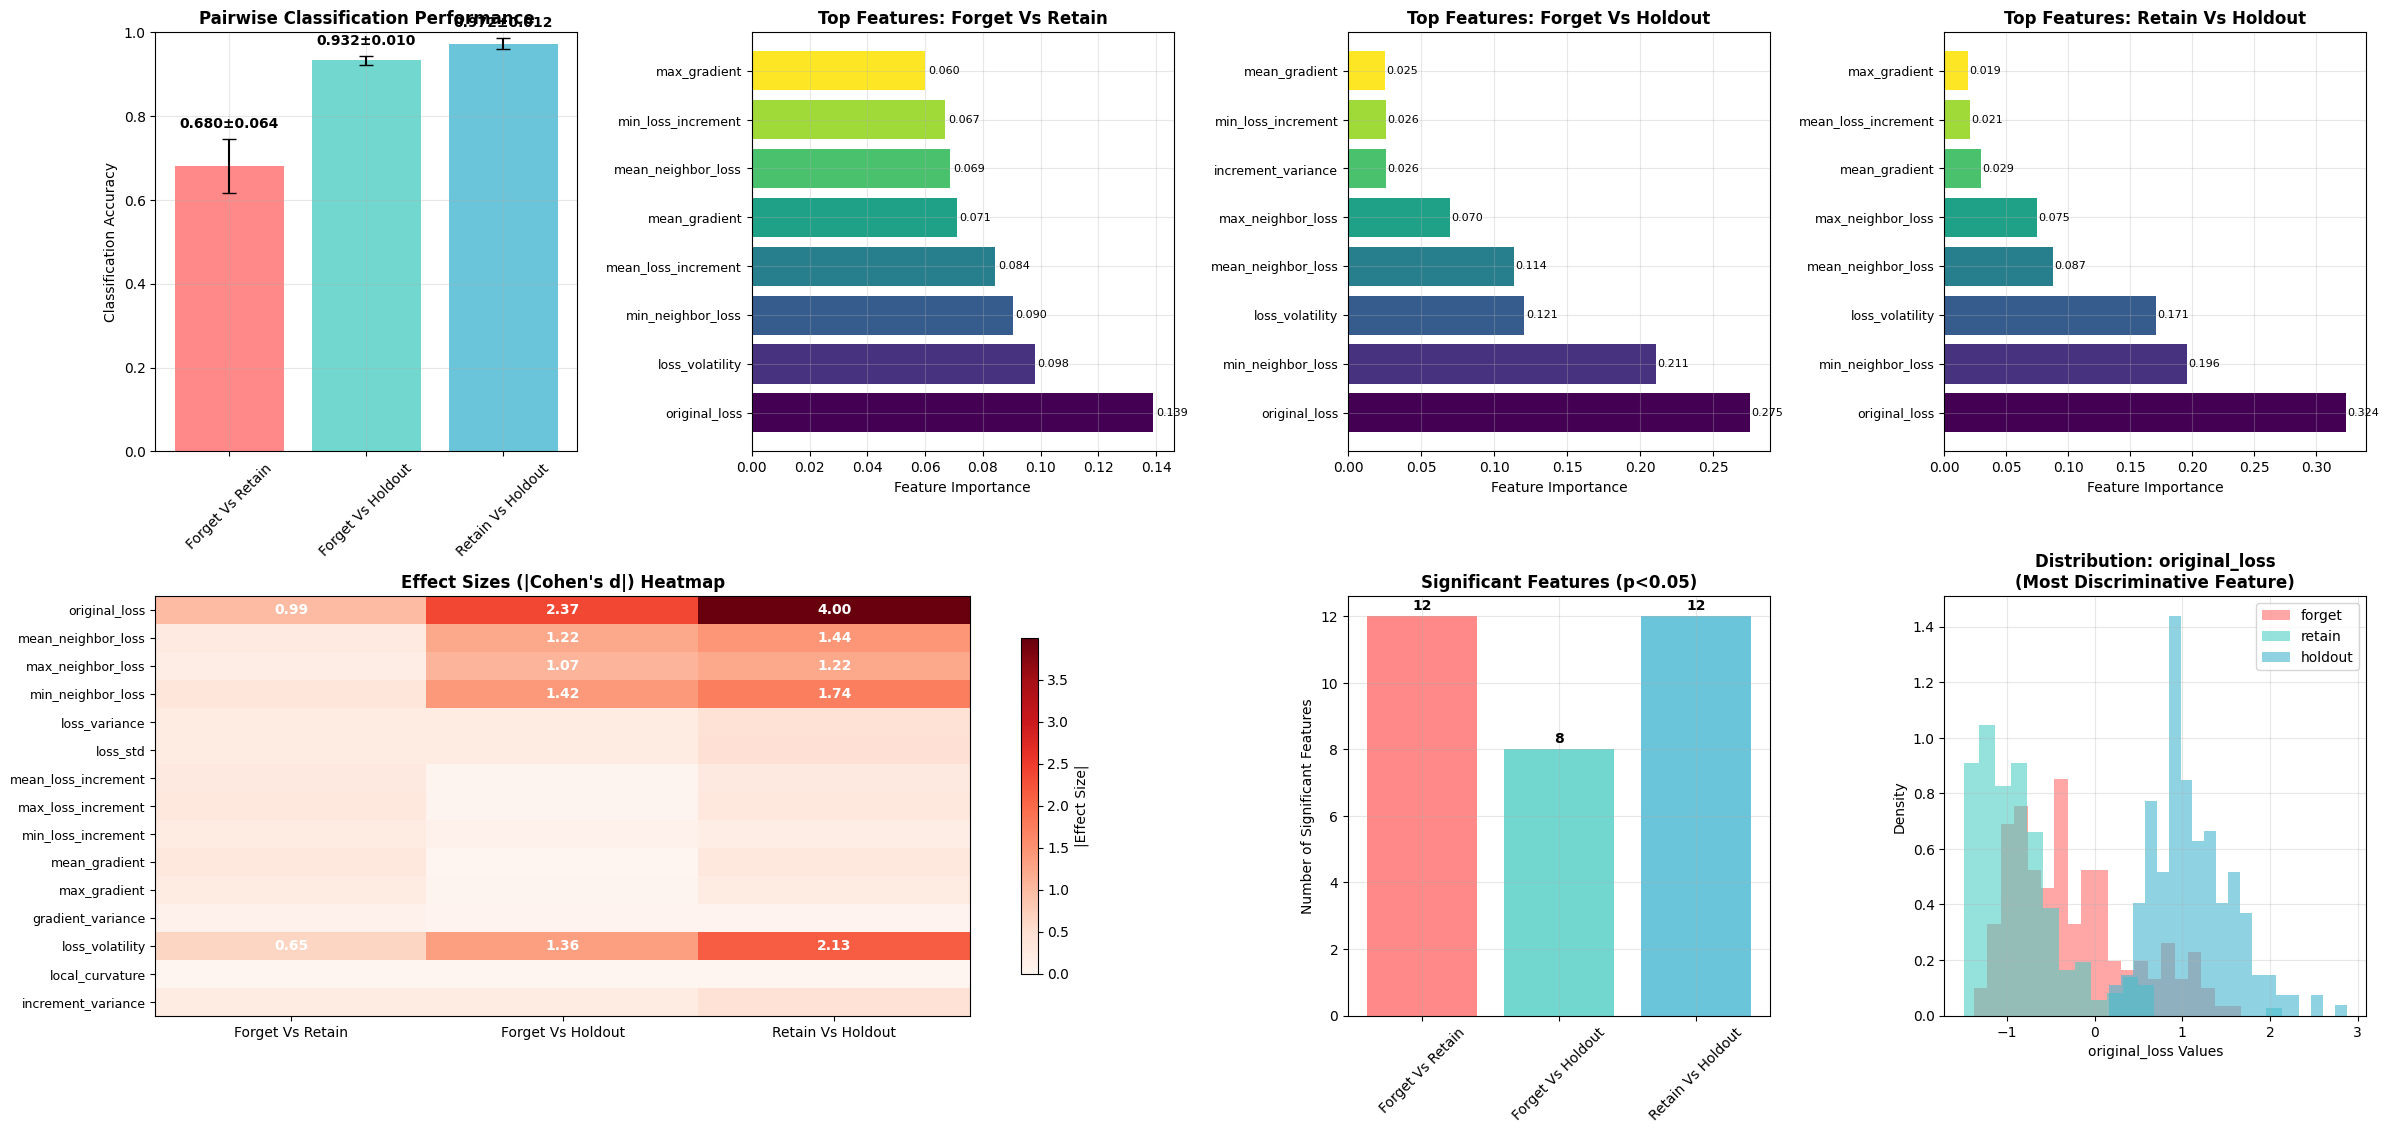


MOST DISCRIMINATIVE FEATURE ACROSS ALL PAIRS: original_loss
Average effect size: 2.452


In [39]:
# Plot comprehensive pairwise discrimination results
best_discriminative_feature, feature_discrimination_scores = eval_with_ILL.plot_pairwise_discrimination_results(pairwise_results, features_labels, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print(f"\nMOST DISCRIMINATIVE FEATURE ACROSS ALL PAIRS: {best_discriminative_feature}")
print(f"Average effect size: {feature_discrimination_scores[best_discriminative_feature]:.3f}")

In [40]:
# ============================================================================
# COMPREHENSIVE ILL DISCRIMINATION SUMMARY
# ============================================================================

def create_ill_discrimination_summary_report(ill_discrimination, boundary_results, pairwise_results, 
                                            best_discriminative_feature, feature_discrimination_scores):
    """
    Generate a comprehensive summary report for ILL-based dataset discrimination.
    """
    print("="*80)
    print("COMPREHENSIVE INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT")
    print("="*80)
    
    # Overall discrimination performance
    print("\n1. OVERALL DISCRIMINATION PERFORMANCE:")
    print("-" * 50)
    overall_cv = ill_discrimination['cv_scores'].mean()
    overall_std = ill_discrimination['cv_scores'].std()
    print(f"3-way classification (Forget/Retain/Holdout): {overall_cv:.3f} ± {overall_std:.3f}")
    
    print("\nClassifier comparison:")
    for clf_name, results in boundary_results.items():
        print(f"  {clf_name:15}: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
    
    # Feature importance summary
    print("\n2. MOST DISCRIMINATIVE ILL FEATURES:")
    print("-" * 50)
    top_features = ill_discrimination['feature_importance'].head(5)
    for idx, row in top_features.iterrows():
        print(f"{row['rank']}. {row['feature']:20}: {row['importance']:.4f}")
    
    # Feature category analysis
    print("\n3. FEATURE CATEGORY DISCRIMINATION POWER:")
    print("-" * 50)
    feature_categories = {
        'Loss-based': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variance-based': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient-based': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment-based': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    category_importance = {}
    for category, features in feature_categories.items():
        category_features = ill_discrimination['feature_importance'][
            ill_discrimination['feature_importance']['feature'].isin(features)
        ]
        category_importance[category] = category_features['importance'].sum()
    
    sorted_categories = sorted(category_importance.items(), key=lambda x: x[1], reverse=True)
    for category, importance in sorted_categories:
        print(f"  {category:15}: {importance:.4f}")
    
    # Pairwise discrimination
    print("\n4. PAIRWISE DISCRIMINATION RESULTS:")
    print("-" * 50)
    for pair_name, results in pairwise_results.items():
        acc = results['classification_accuracy']
        std = results['classification_std']
        n_sig = len(results['significant_features'])
        print(f"{pair_name.replace('_', ' ').title():20}: {acc:.3f}±{std:.3f} ({n_sig} significant features)")
    
    # Best discriminative features
    print(f"\n5. MOST DISCRIMINATIVE FEATURE OVERALL:")
    print("-" * 50)
    print(f"Feature: {best_discriminative_feature}")
    print(f"Average effect size across all pairs: {feature_discrimination_scores[best_discriminative_feature]:.3f}")
    
    # Recommendations
    print("\n6. RECOMMENDATIONS FOR ILL-BASED DISCRIMINATION:")
    print("-" * 50)
    
    best_pair = max(pairwise_results.items(), key=lambda x: x[1]['classification_accuracy'])
    worst_pair = min(pairwise_results.items(), key=lambda x: x[1]['classification_accuracy'])
    
    print(f"• Easiest to distinguish: {best_pair[0].replace('_', ' ')} ({best_pair[1]['classification_accuracy']:.3f})")
    print(f"• Hardest to distinguish: {worst_pair[0].replace('_', ' ')} ({worst_pair[1]['classification_accuracy']:.3f})")
    
    print(f"• Focus on top 3 features: {', '.join(top_features.head(3)['feature'].tolist())}")
    
    most_important_category = sorted_categories[0][0]
    print(f"• Most important feature category: {most_important_category}")
    
    # Best classifier
    best_classifier = max(boundary_results.items(), key=lambda x: x[1]['cv_mean'])
    print(f"• Best performing classifier: {best_classifier[0]} ({best_classifier[1]['cv_mean']:.3f})")
    
    print("\n" + "="*80)
    
    # Save comprehensive results
    comprehensive_ill_results = {
        'discrimination_analysis': ill_discrimination,
        'boundary_analysis': boundary_results,
        'pairwise_analysis': pairwise_results,
        'best_discriminative_feature': best_discriminative_feature,
        'feature_discrimination_scores': feature_discrimination_scores,
        'feature_categories': feature_categories,
        'category_importance': category_importance
    }
    
    results_file = f'{plots_base_dir}/comprehensive_ill_discrimination_results.pkl'
    with open(results_file, 'wb') as f:
        pickle.dump(comprehensive_ill_results, f)
    
    print(f"Complete ILL discrimination results saved to: {results_file}")
    
    return comprehensive_ill_results

# Generate comprehensive ILL discrimination summary
comprehensive_ill_results = create_ill_discrimination_summary_report(
    ill_discrimination, boundary_results, pairwise_results, 
    best_discriminative_feature, feature_discrimination_scores
)

print("\n" + "="*60)
print("ILL DISCRIMINATION ANALYSIS COMPLETE!")
print("="*60)
print("Generated specialized plots:")
print("1. ILL feature importance and discrimination analysis")
print("2. Pairwise discrimination comprehensive analysis")
print("3. Confusion matrices and cross-validation results")
print("4. Feature category importance analysis")
print("5. Decision boundary complexity analysis")
print("="*60)

COMPREHENSIVE INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT

1. OVERALL DISCRIMINATION PERFORMANCE:
--------------------------------------------------
3-way classification (Forget/Retain/Holdout): 0.747 ± 0.035

Classifier comparison:
  Linear SVM     : 0.742 ± 0.020
  RBF SVM        : 0.720 ± 0.029
  Decision Tree  : 0.687 ± 0.036
  Naive Bayes    : 0.705 ± 0.044
  Random Forest  : 0.750 ± 0.029

2. MOST DISCRIMINATIVE ILL FEATURES:
--------------------------------------------------
1. original_loss       : 0.2118
2. min_neighbor_loss   : 0.1425
3. loss_volatility     : 0.1244
4. mean_neighbor_loss  : 0.0828
5. max_neighbor_loss   : 0.0716

3. FEATURE CATEGORY DISCRIMINATION POWER:
--------------------------------------------------
  Loss-based     : 0.5086
  Increment-based: 0.1313
  Landscape      : 0.1244
  Gradient-based : 0.1187
  Variance-based : 0.1170

4. PAIRWISE DISCRIMINATION RESULTS:
--------------------------------------------------
Forget Vs Retain    : 0.680±0.064 (1

In [41]:
# Specialized Input Loss Landscape (ILL) Analysis Functions

def analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze loss landscape features by semantic categories relevant to ILL.
    """
    # Define feature categories for ILL analysis
    feature_categories = {
        'Base Loss': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variability': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    category_analysis = {}
    
    # Analyze each category
    for category, features in feature_categories.items():
        category_data = {}
        
        for dataset_name, tensor in datasets.items():
            category_features = []
            for feature in features:
                if feature in features_labels:
                    feat_idx = features_labels.index(feature)
                    category_features.append(tensor[:, feat_idx].numpy())
            
            if category_features:
                category_tensor = np.column_stack(category_features)
                
                # Compute category-level statistics
                category_data[dataset_name] = {
                    'mean_values': np.mean(category_tensor, axis=0),
                    'std_values': np.std(category_tensor, axis=0),
                    'category_mean': np.mean(category_tensor),
                    'category_std': np.std(category_tensor),
                    'feature_correlations': np.corrcoef(category_tensor.T),
                    'feature_names': [f for f in features if f in features_labels]
                }
        
        category_analysis[category] = category_data
    
    return category_analysis

# Run category analysis
print("Analyzing ILL features by semantic categories...")
category_analysis = analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Analyzing ILL features by semantic categories...


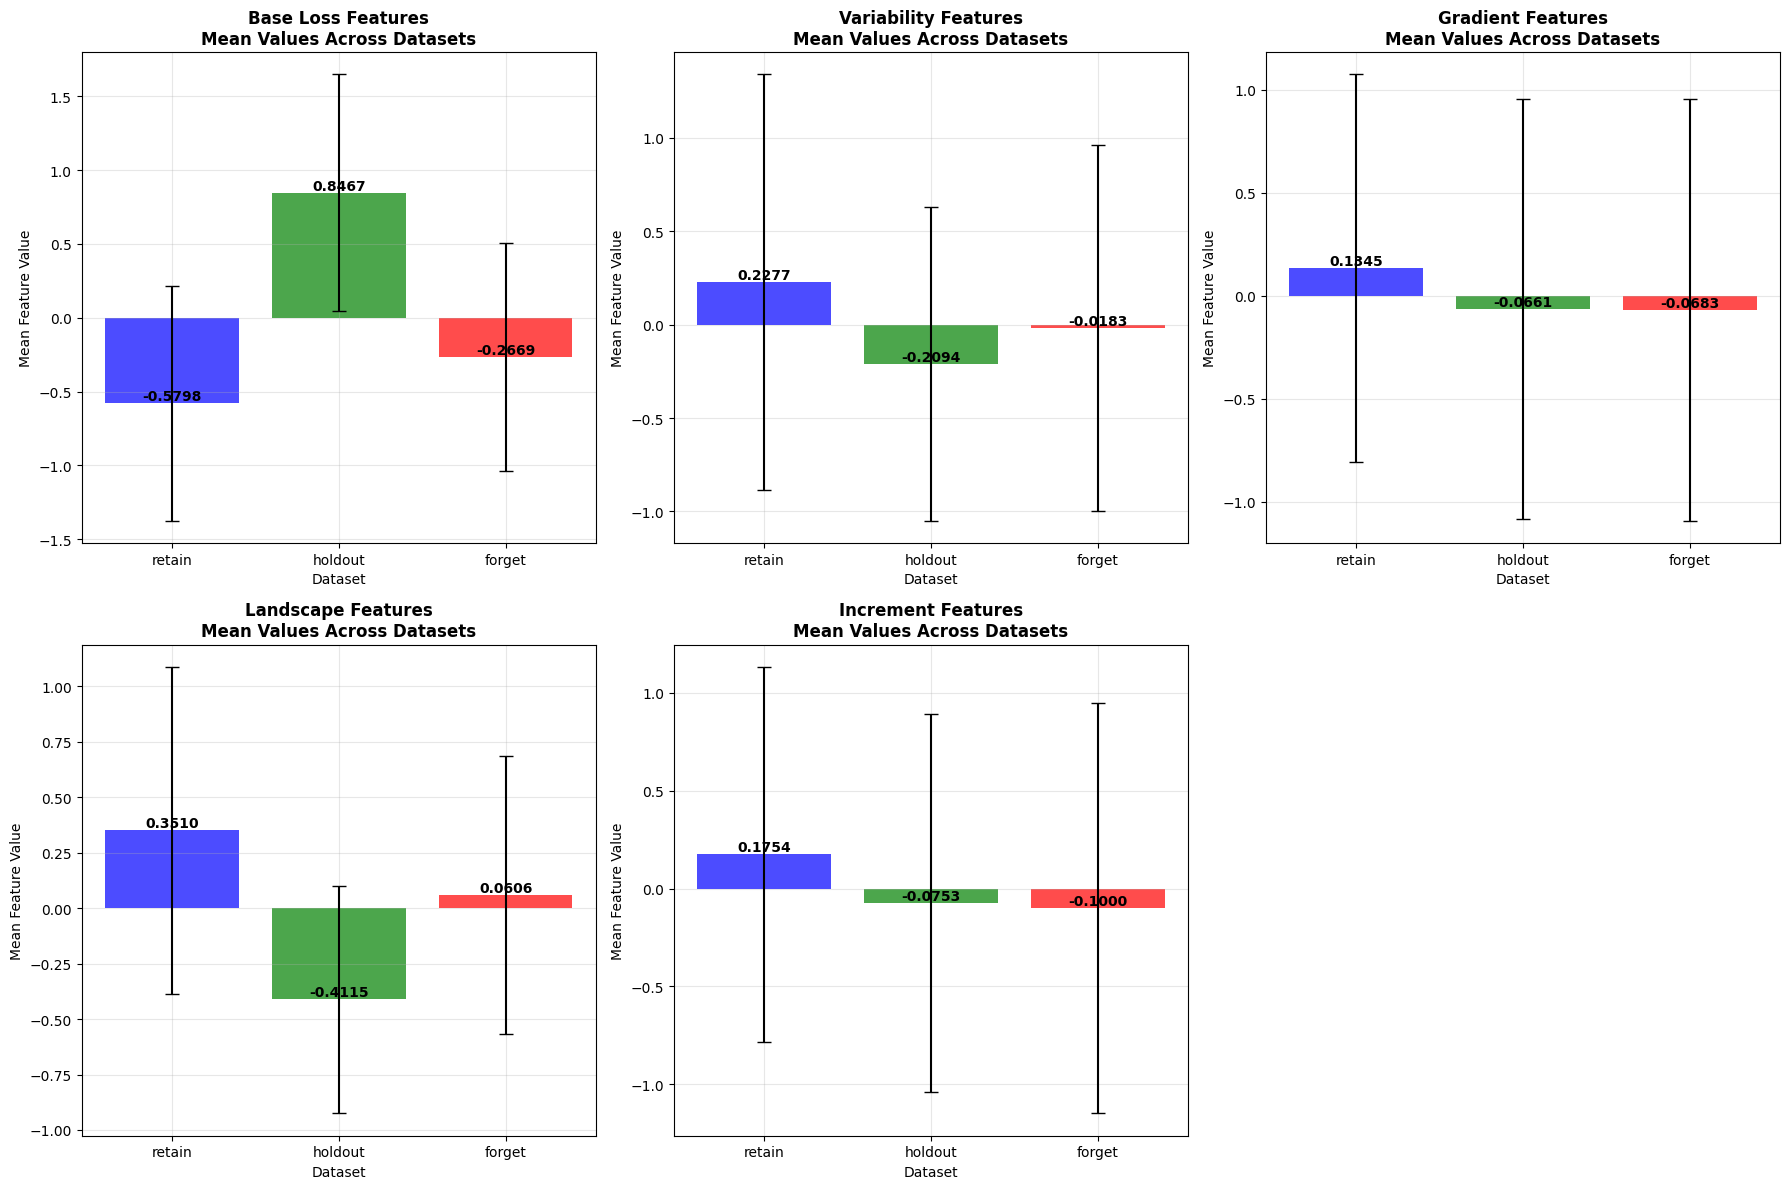

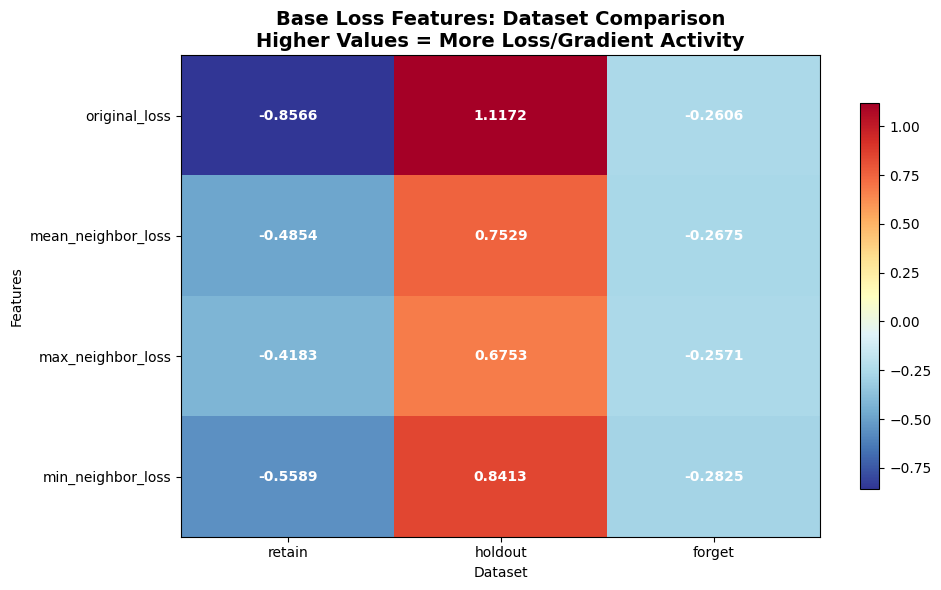

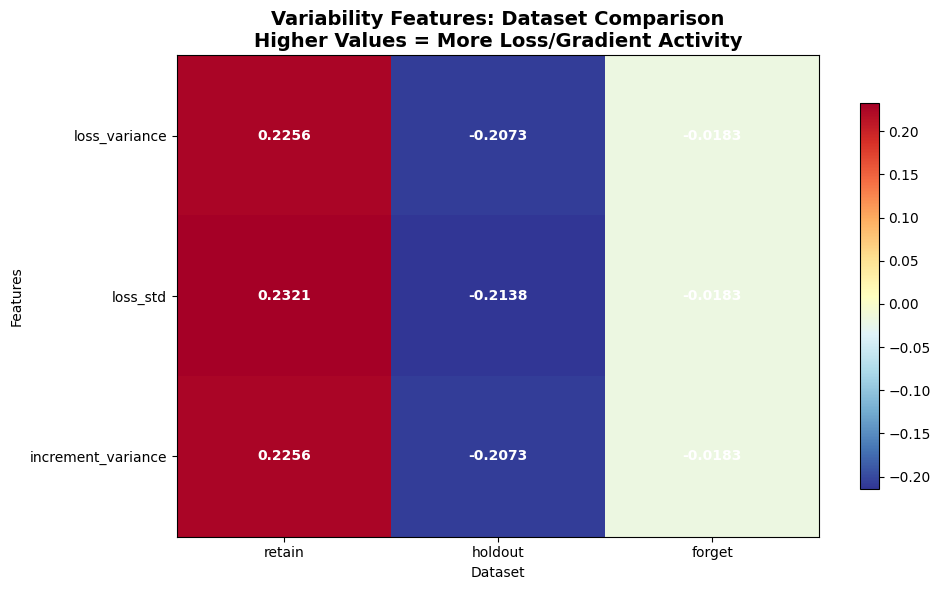

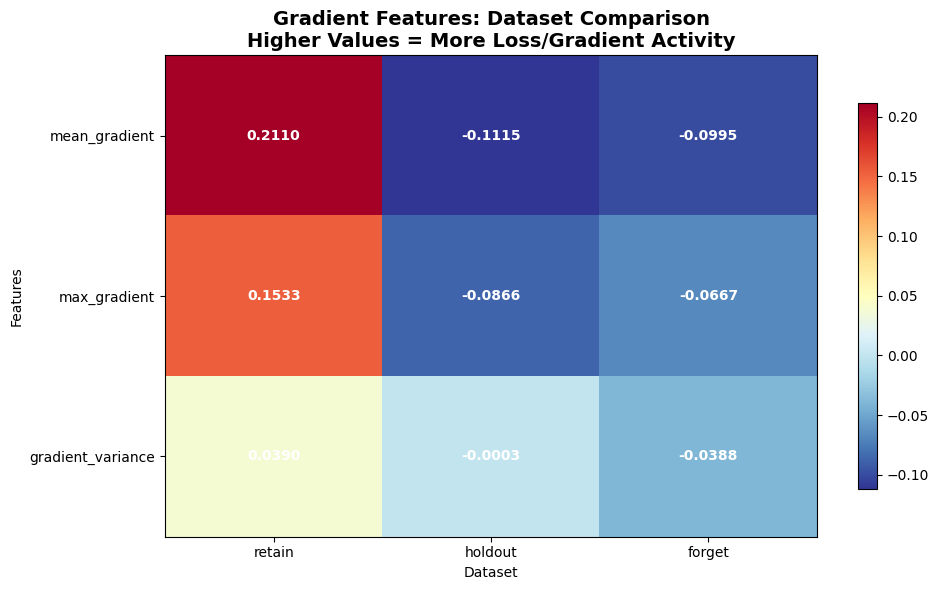

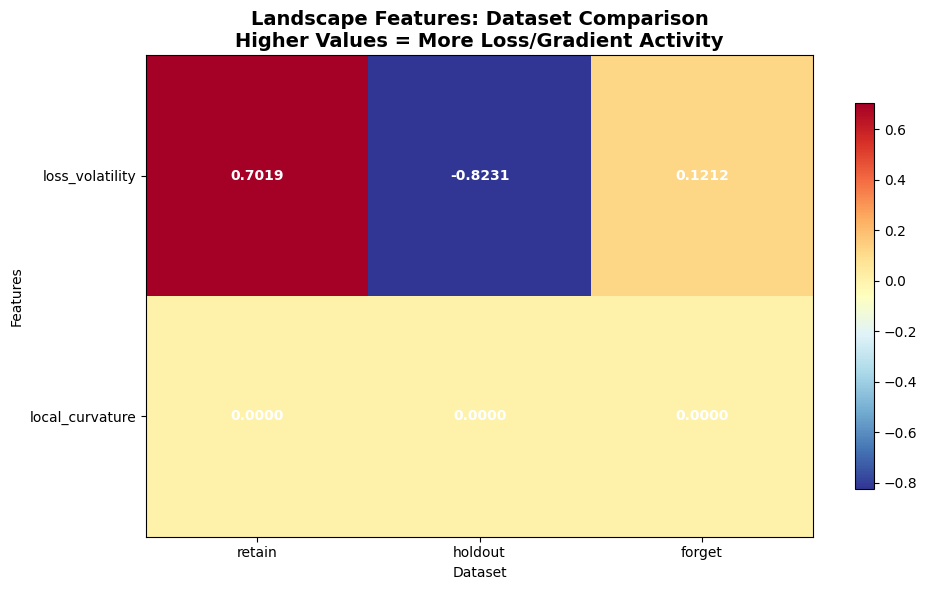

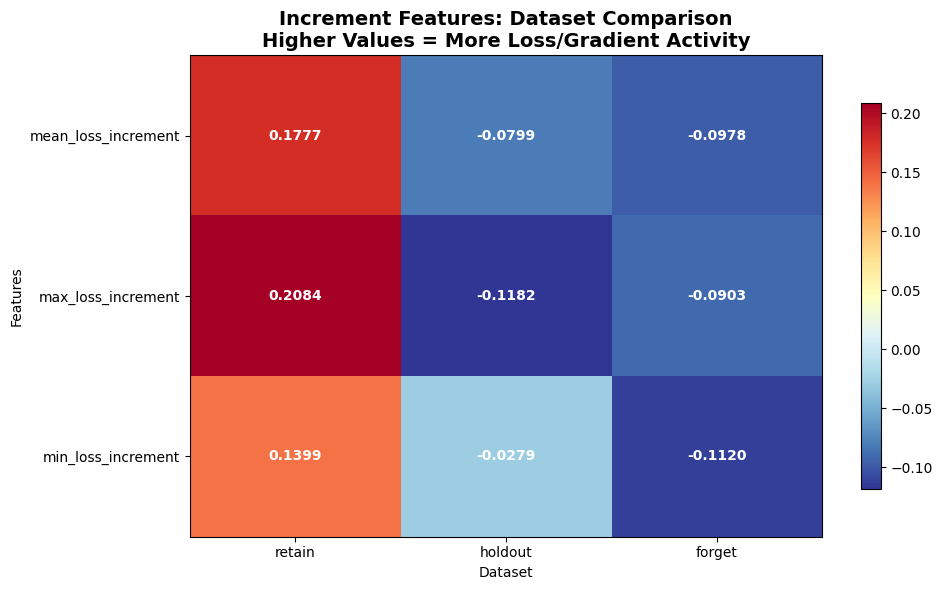

In [42]:
# Visualize ILL Category Analysis
def plot_ill_category_analysis(category_analysis):
    """
    Create comprehensive visualizations for ILL category analysis.
    """
    categories = list(category_analysis.keys())
    datasets = ['retain', 'holdout', 'forget']
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    # 1. Category-level means comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        category_means = []
        category_stds = []
        
        for dataset in datasets:
            if dataset in category_analysis[category]:
                category_means.append(category_analysis[category][dataset]['category_mean'])
                category_stds.append(category_analysis[category][dataset]['category_std'])
            else:
                category_means.append(0)
                category_stds.append(0)
        
        x_pos = np.arange(len(datasets))
        bars = ax.bar(x_pos, category_means, yerr=category_stds, 
                     color=[colors[d] for d in datasets], alpha=0.7, capsize=5)
        
        ax.set_title(f'{category} Features\nMean Values Across Datasets', fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Mean Feature Value')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(datasets)
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, category_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplot
    if len(categories) < len(axes):
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/ill_category_means.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # 2. Feature-level heatmap for each category
    for category in categories:
        if category not in category_analysis:
            continue
            
        # Get feature names for this category
        feature_names = None
        for dataset in datasets:
            if dataset in category_analysis[category]:
                feature_names = category_analysis[category][dataset]['feature_names']
                break
        
        if not feature_names:
            continue
            
        # Create data matrix
        data_matrix = []
        for feature_idx in range(len(feature_names)):
            row = []
            for dataset in datasets:
                if dataset in category_analysis[category]:
                    row.append(category_analysis[category][dataset]['mean_values'][feature_idx])
                else:
                    row.append(0)
            data_matrix.append(row)
        
        data_matrix = np.array(data_matrix)
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names)*0.8)))
        im = ax.imshow(data_matrix, cmap='RdYlBu_r', aspect='auto')
        
        ax.set_title(f'{category} Features: Dataset Comparison\nHigher Values = More Loss/Gradient Activity', 
                    fontweight='bold', fontsize=14)
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Features')
        ax.set_xticks(range(len(datasets)))
        ax.set_yticks(range(len(feature_names)))
        ax.set_xticklabels(datasets)
        ax.set_yticklabels(feature_names)
        
        # Add text annotations
        for i in range(len(feature_names)):
            for j in range(len(datasets)):
                text = ax.text(j, i, f'{data_matrix[i, j]:.4f}',
                              ha="center", va="center", color="white", fontweight='bold')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout()
        plt.savefig(f'{plots_base_dir}/ill_{category.lower()}_features.png', bbox_inches='tight', dpi=150)
        plt.show()

# Plot ILL category analysis
plot_ill_category_analysis(category_analysis)

In [43]:
# Sentence Embedding Analysis for Semantic Landscape
def analyze_semantic_embeddings(forget_data, holdout_data, retain_data):
    """
    Analyze sentence embeddings to understand semantic patterns in loss landscapes.
    """
    from sentence_transformers import SentenceTransformer
    
    # Load a sentence transformer model
    try:
        embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
        print("Using SentenceTransformer for semantic analysis...")
    except:
        print("SentenceTransformer not available. Install with: pip install sentence-transformers")
        return None
    
    # Extract texts from data
    datasets = {
        'forget': [item['text'] for item in forget_data if item.get('valid_example', True)],
        'holdout': [item['text'] for item in holdout_data if item.get('valid_example', True)],
        'retain': [item['text'] for item in retain_data if item.get('valid_example', True)]
    }
    
    # Limit to reasonable sample size for computation
    max_samples = 500
    for dataset_name in datasets:
        if len(datasets[dataset_name]) > max_samples:
            datasets[dataset_name] = datasets[dataset_name][:max_samples]
            print(f"Limiting {dataset_name} to {max_samples} samples for embedding analysis")
    
    # Compute embeddings
    embedding_results = {}
    
    for dataset_name, texts in datasets.items():
        print(f"Computing embeddings for {dataset_name} dataset ({len(texts)} samples)...")
        embeddings = embedding_model.encode(texts, show_progress_bar=True)
        
        embedding_results[dataset_name] = {
            'embeddings': embeddings,
            'texts': texts,
            'embedding_mean': np.mean(embeddings, axis=0),
            'embedding_std': np.std(embeddings, axis=0),
            'centroid': np.mean(embeddings, axis=0),
            'intra_cluster_distance': np.mean(pdist(embeddings))
        }
    
    return embedding_results

# Run semantic embedding analysis
print("Analyzing sentence embeddings for semantic landscape patterns...")
try:
    semantic_results = analyze_semantic_embeddings(forget_data, holdout_data, retain_data)
except Exception as e:
    print(f"Semantic analysis failed: {e}")
    print("Continuing with other analyses...")
    semantic_results = None

Analyzing sentence embeddings for semantic landscape patterns...
Semantic analysis failed: name 'forget_data' is not defined
Continuing with other analyses...


# Experiment - Data Extraction

In these experiments we try to extract the original sentence based on ite neighbor ILL

lets define terms:
1st_neighbor_of_origin - the sentence we fed to the model (the target)
origin_ground_truth = origin_GT - the sentence that the 1st_neighbor_of_origin was created from
neighbors - neighbors generated from the 1st_neighbor_of_origin